In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18


# Import packages

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need

from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial
import pygwalker as pyg

0.1.0


# Miscellaneous functions

In [3]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)# Matplotlib plot
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

# Define local path

In [4]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


# Data Import

In [5]:
fpath = f'{local_github_path}/data/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['deltaRI_flip'] = raw_coretop_df['ringIndex'] - raw_coretop_df['TEX_RI']

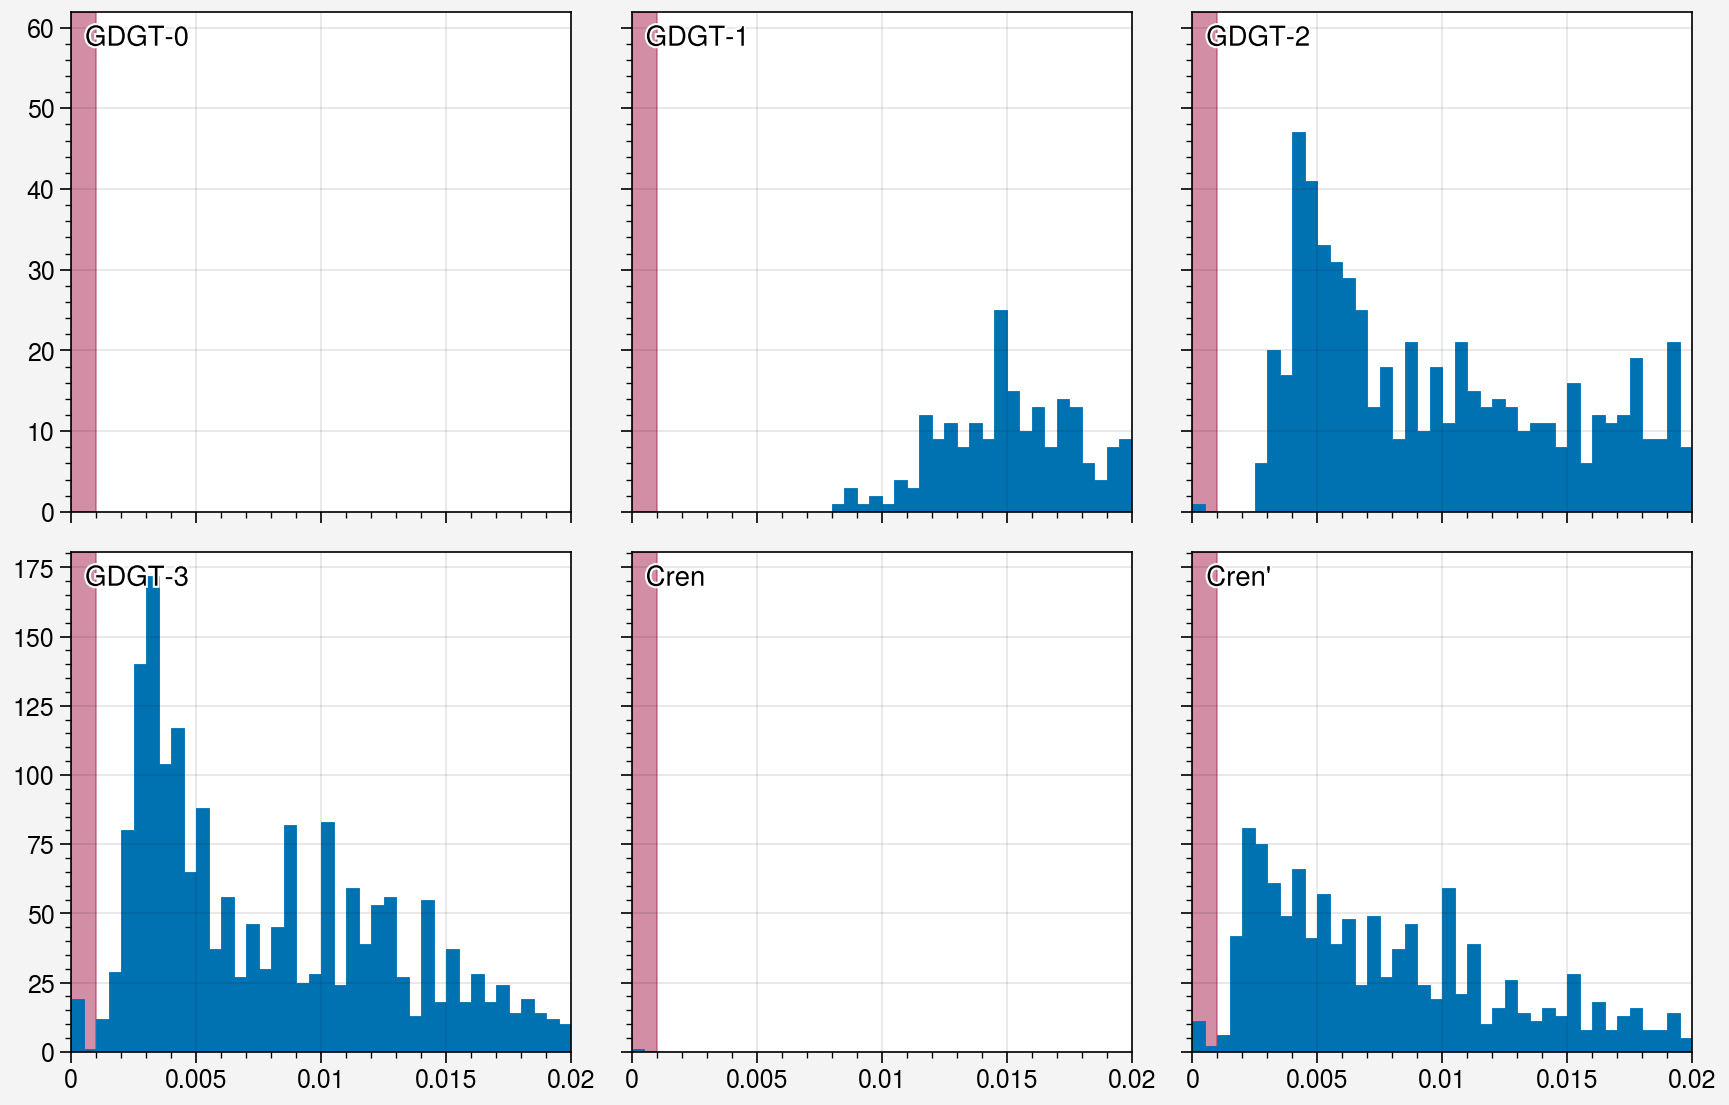

In [6]:
fig, axs = plot.subplots(ncols=3,nrows=2)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
plot_data = raw_coretop_df.dropna(how='any',subset=features)

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]
    ax.format(ultitle=f'{label}',fontweight='bold')
    XX = plot_data[feature].values
    ax.hist(XX,bins=np.arange(XX.min(),XX.max(),0.0005))
    
axs.format(xlim=(0,0.02))
axs.axvspan(0,0.001, color='pink9', alpha=0.5, edgecolor='none', zorder=0)

plt.show()

In [7]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
clean_coretop_df = raw_coretop_df[(raw_coretop_df['QC_flag']=='include') & (raw_coretop_df[features]>0.001).all(axis=1)].reset_index(drop=True)

clean_coretop_df['predRI_multiv_g23r'] = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=clean_coretop_df['thermocline_T_depthIntegral'],
            gdgt23ratio=clean_coretop_df['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']
clean_coretop_df['RIres_multiv_g23r'] = clean_coretop_df['scaledRI'] - clean_coretop_df['predRI_multiv_g23r']

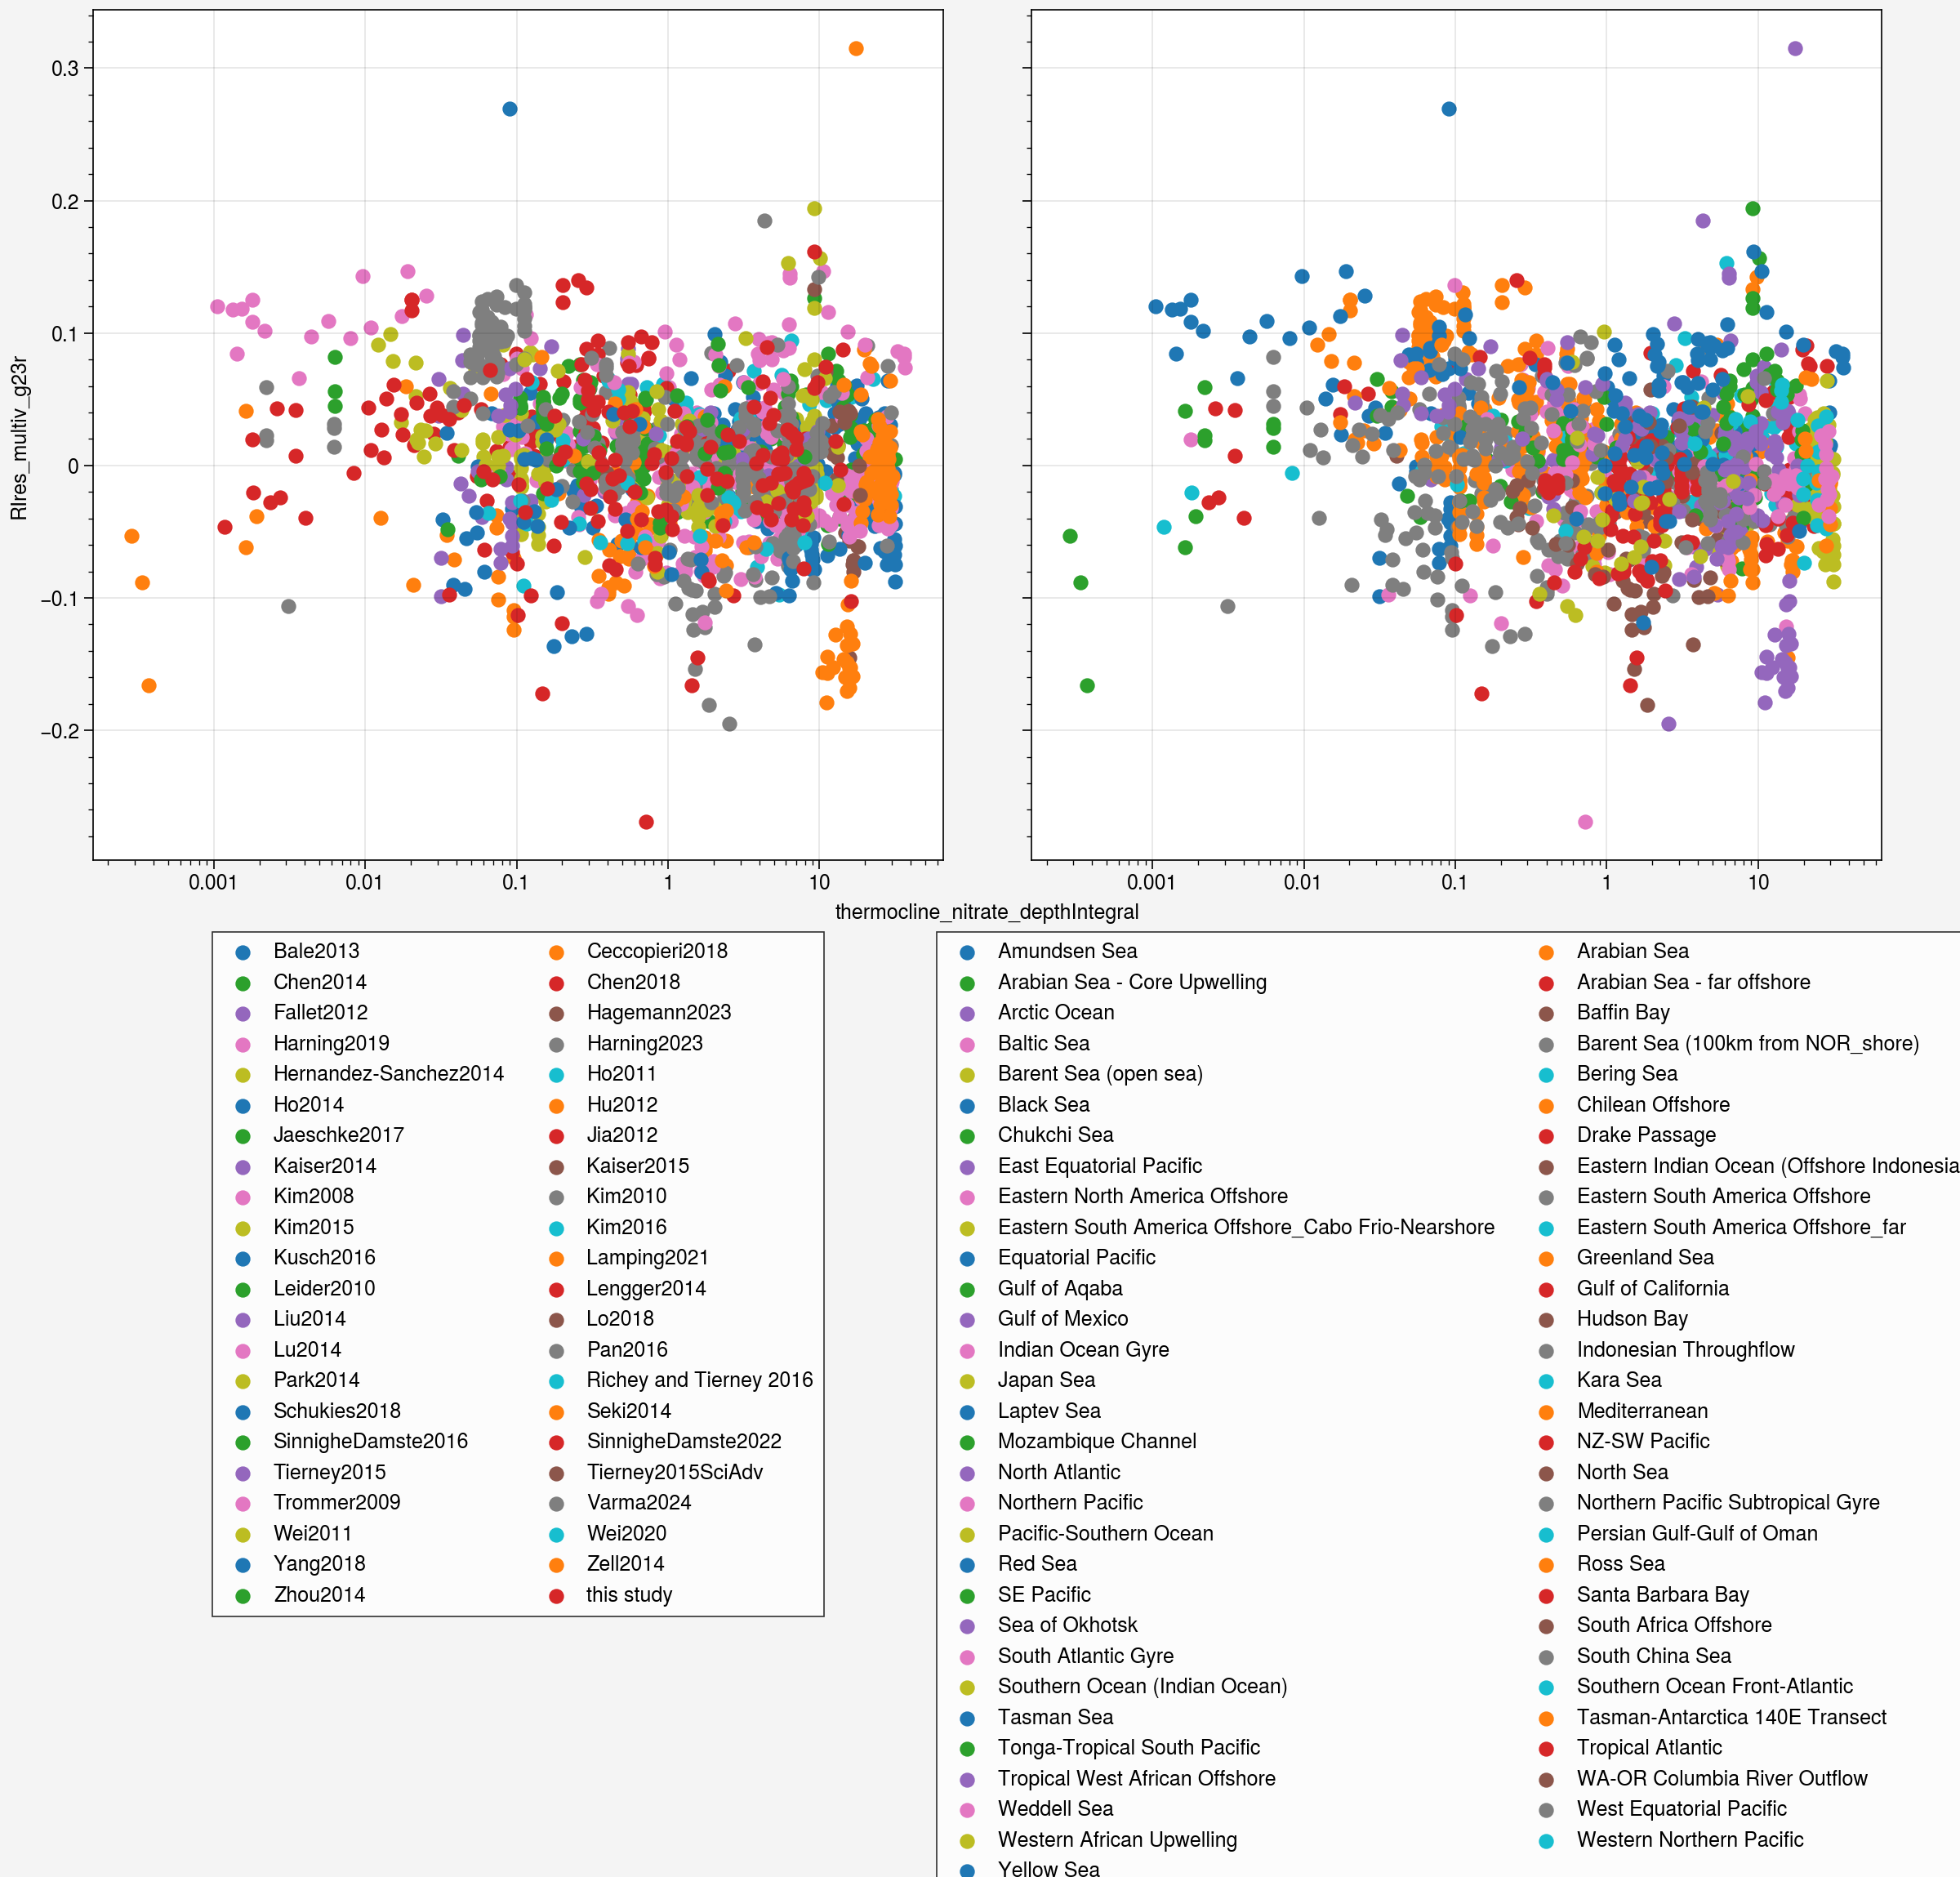

In [8]:
fig, axs = plot.subplots(ncols=2,width=12)

plot_data = clean_coretop_df
grouped = plot_data.groupby('reference_name')
for name, group in grouped:
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']

    ax = axs[0]
    ax.scatter(plot_x,plot_y,cycle='tab10',label=name)
    ax.format(
        xscale='log'
    )
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h,l,loc='b',ncols=2, fontsize=8)


grouped2 = plot_data.groupby('regionName')
for name2, group2 in grouped2:
    plot_x = group2['thermocline_nitrate_depthIntegral']
    plot_y = group2['RIres_multiv_g23r']

    ax = axs[1]
    ax.scatter(plot_x,plot_y,cycle='tab10',label=name2)
    ax.format(
        xscale='log'
    )
h2, l2 = axs[1].get_legend_handles_labels()
axs[1].legend(h2,l2,loc='b',ncols=2, fontsize=8)

In [9]:
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'global_hydrothermal_vents.csv'

glob_hydrovent = pd.read_csv(os.path.join(fpath,fname))
glob_hydrovent['longitude'] = pd.to_numeric(glob_hydrovent['longitude'], errors='coerce')
glob_hydrovent['latitude'] = pd.to_numeric(glob_hydrovent['latitude'], errors='coerce')
glob_hydrovent = glob_hydrovent.dropna(how='any',subset=['longitude','latitude'])
glob_hydrovent

,Name,longitude,latitude,Site Activity,Activity,Tectonic setting,Spreading Rate,Depth
0,Kagamil Island,-169.7200,52.980000,VolcanicArc-active,active,arc volcano,NotApplicable,5
1,Piip Submarine Volcano,167.2717,55.416700,VolcanicArc-active,active,arc volcano,NotApplicable,500-382
2,Paramushir Island,155.5000,49.666700,VolcanicArc-inactive,inactive,arc volcano,NotApplicable,800
3,Kraternaya Bight; Ushishir Volcano,152.8000,47.516667,VolcanicArc-active,active,arc volcano,NotApplicable,60-0
4,Hot Beach; Mendeleev Volcano,145.7360,43.976000,VolcanicArc-active,active,arc volcano,NotApplicable,1-0
...,...,...,...,...,...,...,...,...
549,SEIR; 21,79.1030,-41.252000,MOR-unconfirmed,unconfirmed,MOR,65.9,2800
550,SEIR; 16,79.7530,-41.772000,MOR-unconfirmed,unconfirmed,MOR,66.3,2800
551,SEIR; 10,81.8380,-41.802000,MOR-unconfirmed,unconfirmed,MOR,67.1,2540
552,SEIR; 01,88.0420,-42.113000,MOR-unconfirmed,unconfirmed,MOR,68.5,2400


In [10]:
from sklearn.neighbors import BallTree

threshold_km = 5
R_km = 6371.0088

df1 = clean_coretop_df
df2 = glob_hydrovent
# radians
df1_rad = np.deg2rad(df1[['Latitude','Longitude']].to_numpy())
df2_rad = np.deg2rad(df2[['latitude','longitude']].to_numpy())

# build tree on df2 points
tree = BallTree(df2_rad, metric='haversine')

# query all df1 points within radius (in radians)
radius = threshold_km / R_km
neighbors = tree.query_radius(df1_rad, r=radius)

# label: near if at least one match, else far
dist_rad, _ = tree.query(df1_rad, k=1)   # nearest neighbor
df1['dist_km'] = (dist_rad.flatten() * R_km)
df1['near_far'] = np.where(df1['dist_km'] <= threshold_km, 'near', 'far')

df1.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'deltaRI_group', 'deltaRI_flip',
       'predRI_multiv_g23r', 'RIres_multiv_g23r', 'dist_km', 'near_far'],
      dtype='object')

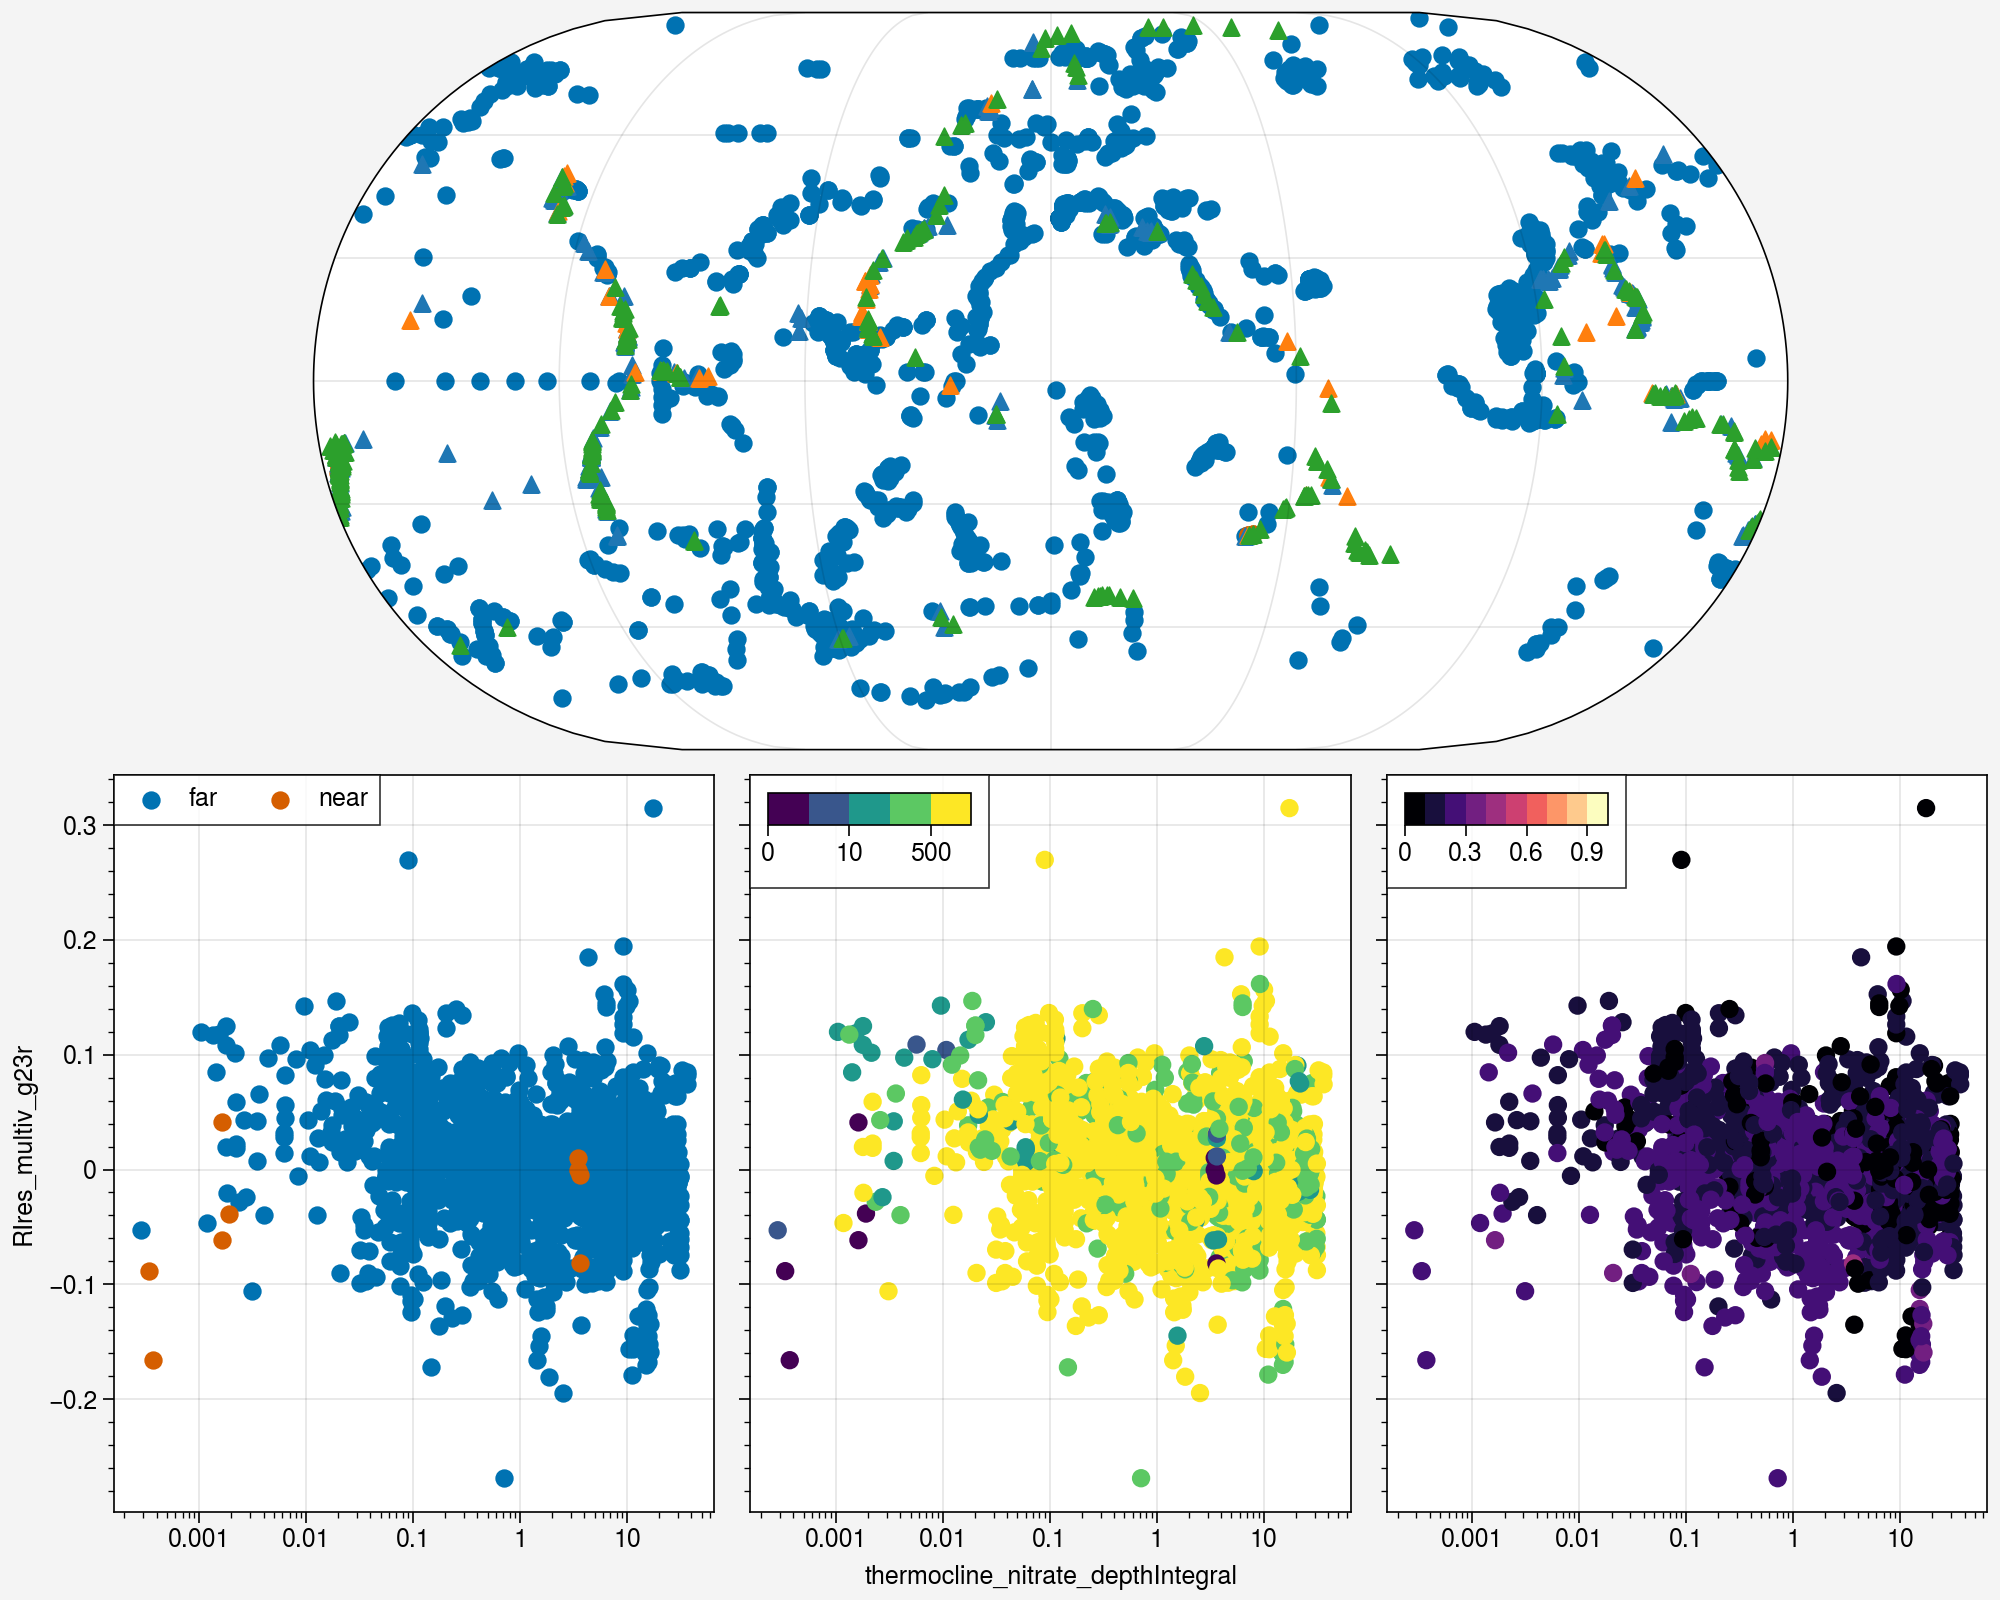

In [11]:
array = [
    [1,1,1],
    [2,3,4]
]

fig, axs = plot.subplots(array,figsize=(10,8),proj=('eck3',None))

ax = axs[0]
grouped = df1.groupby('near_far')
for name, group in grouped:
    plot_x = group['Longitude']
    plot_y = group['Latitude']
    ax.scatter(plot_x,plot_y)
    
    plot_x2 = group['thermocline_nitrate_depthIntegral']
    plot_y2 = group['RIres_multiv_g23r']
    axs[1].scatter(plot_x2,plot_y2,label=name)
    
grouped_hydrovent = glob_hydrovent.groupby('Activity')
for name, group in grouped_hydrovent:
    plot_x = group['longitude']
    plot_y = group['latitude']
    ax.scatter(plot_x.astype(float),plot_y.astype(float),m='^',cycle='tab10')

ax = axs[2]
plot_data = df1
plot_x = plot_data['thermocline_nitrate_depthIntegral']
plot_y = plot_data['RIres_multiv_g23r']
plot_c = plot_data['dist_km']
m = ax.scatter(plot_x,plot_y,c=plot_c,cmap='viridis',levels=[0,5,10,100,500,1000])
ax.colorbar(m, loc='ul')

ax = axs[3]
plot_data = df1
plot_x = plot_data['thermocline_nitrate_depthIntegral']
plot_y = plot_data['RIres_multiv_g23r']
plot_c = plot_data['methaneIndex']
m = ax.scatter(plot_x,plot_y,c=plot_c,cmap='magma',levels=np.arange(0,1.1,0.1))
ax.colorbar(m, loc='ul')

axs[1,:].format(xscale='log')

h1, l1 = axs[1].get_legend_handles_labels()
axs[1].legend(h1,l1,loc='ul')

(0.0, 10.0)

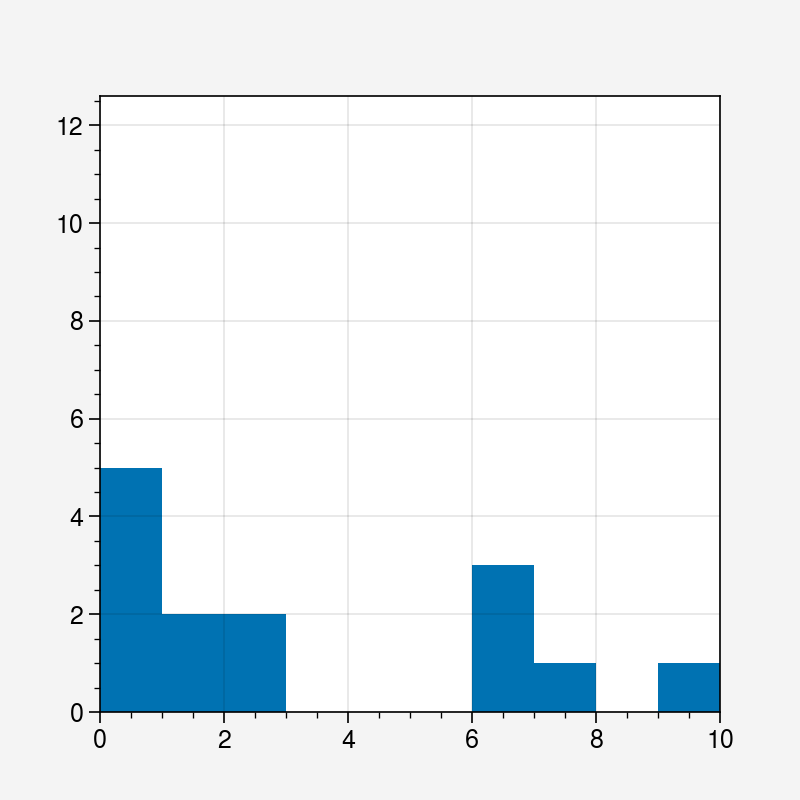

In [12]:
plt.hist(df1.dist_km,bins=np.arange(0,3501,1))
plt.xlim(0,10)

# Main Figures

## Figure 1: Global Coretop Map

In [13]:
culmeso_df = pd.read_excel(f"{local_github_path}/data/spreadsheets/revised_cultures_GDGT_github_March2025_RR.xlsx", sheet_name="master_cultures")
culmeso_df

,sampleName,Strains,organism_reported_names,phyloT_order,GTDB_phylum,GTDB_class,GTDB_order,GTDB_family,GTDB_genus,GTDB_species,...,incomplete_GDGT_fractions,BIT_QC_above05,gdgt0Cren_QC_above07,MI_QC_above05,QC_Indices_check,detectionLimit_check,Source2,firstAuthor_firstName,DOI,Taxonomy data update
0,Bale2019_001_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,No,Not reported; Assumed no brGDGTs (cultures),No,Yes,Fail,Fail,Bale et al. (2019),Nicole,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...
1,Bale2019_002_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,No,Not reported; Assumed no brGDGTs (cultures),No,No,Pass,Fail,Bale et al. (2019),Nicole,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...
2,Bale2019_003_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,No,Not reported; Assumed no brGDGTs (cultures),No,No,Pass,Fail,Bale et al. (2019),Nicole,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...
3,Bale2019_004_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,No,Not reported; Assumed no brGDGTs (cultures),No,Yes,Fail,Fail,Bale et al. (2019),Nicole,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...
4,Bale2019_005_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,No,Not reported; Assumed no brGDGTs (cultures),No,No,Pass,Fail,Bale et al. (2019),Nicole,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,Elling_etal_unpubl_Nmaritimus_SCM1_28-2_CR15,SCM1,Nitrosopumilus maritimus SCM1,7.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosopumilus,s__Nitrosopumilus maritimus,...,No,Not reported,No,No,Pass,Pass,Elling et al. (unpublished),Felix,Unpublished dataset,Unpublished dataset
212,Elling_etal_unpubl_Nmaritimus_SCM1_28-3_CR16,SCM1,Nitrosopumilus maritimus SCM1,7.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosopumilus,s__Nitrosopumilus maritimus,...,No,Not reported,No,No,Pass,Pass,Elling et al. (unpublished),Felix,Unpublished dataset,Unpublished dataset
213,Elling_etal_unpubl_Nmaritimus_SCM1_32-1_CR17,SCM1,Nitrosopumilus maritimus SCM1,7.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosopumilus,s__Nitrosopumilus maritimus,...,No,Not reported,No,No,Pass,Pass,Elling et al. (unpublished),Felix,Unpublished dataset,Unpublished dataset
214,Elling_etal_unpubl_Nmaritimus_SCM1_32-2_CR18,SCM1,Nitrosopumilus maritimus SCM1,7.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosopumilus,s__Nitrosopumilus maritimus,...,No,Not reported,No,No,Pass,Pass,Elling et al. (unpublished),Felix,Unpublished dataset,Unpublished dataset


Finding the smallest clade containing all target species...
Focused tree on the ancestor 2 level(s) up from the MRCA.


Text(0.5, 0, 'Branch Length')

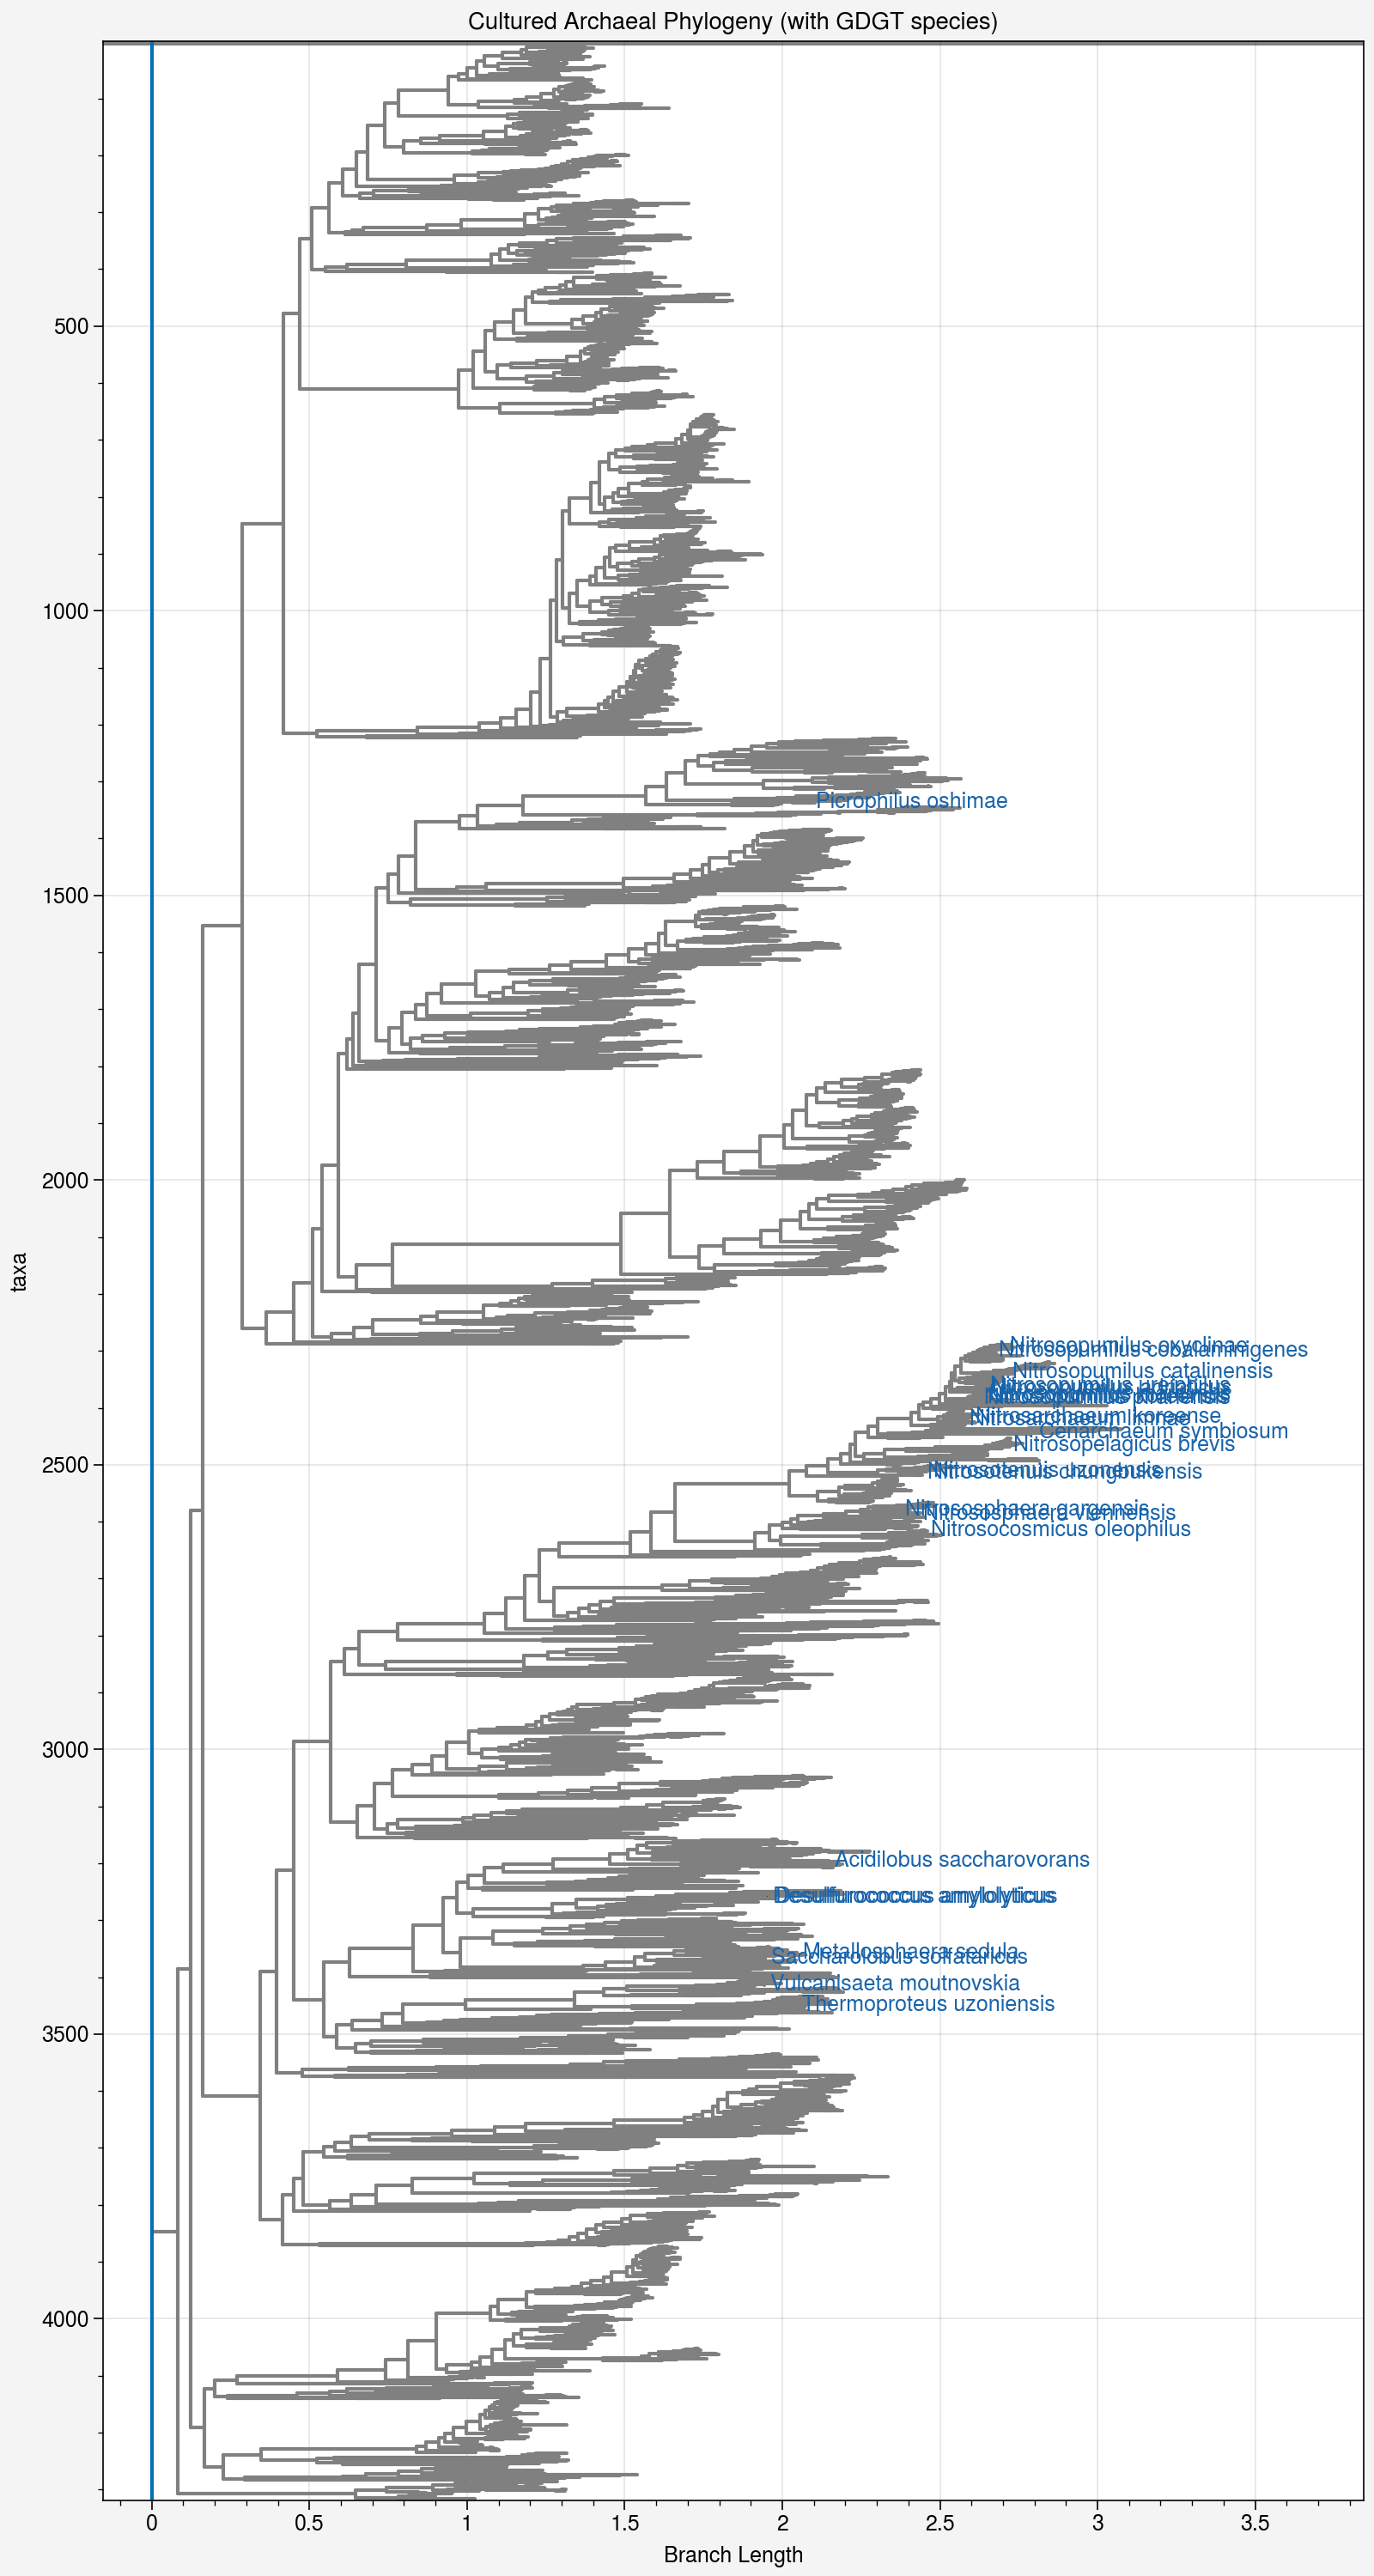

In [14]:
from Bio import Phylo
import matplotlib.pyplot as plt
from pathlib import Path

# ===================================================================
# --- 1. SETUP & DATA LOADING ---
# ===================================================================

# Paths
# local_github_path = "..." # Make sure this is defined
tree_file = f"{local_github_path}/data/phylo/trees/texas_genome_phylogenetic.tree"
species_file = f"{local_github_path}/data/phylo/texas_genome_species_list.txt"

# Helper functions (your functions are good, no changes needed)
def norm_acc(x: str) -> str:
    x = x.strip()
    if x.startswith("user_"):
        x = x[5:]
    return x

def variants(acc: str):
    base = norm_acc(acc)
    base_novers = base.split('.')[0]
    return {base, f"user_{base}", base_novers, f"user_{base_novers}"}

# Load species mapping (accession -> name)
mapping = {}
with open(species_file) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        left, right = line.split("->", 1)
        acc = left.strip()
        name = right.strip()
        for v in variants(acc):
            mapping[v] = name

# --- Read the full tree ---
tree = Phylo.read(tree_file, "newick")


# ===================================================================
# --- 2. TREE MANIPULATION (FINAL VERSION w/ STRATEGIC PRUNING) ---
# ===================================================================

# --- Relabel the tree tips first ---
# (Your relabeling code here is correct)
for cl in tree.get_terminals():
    if cl.name in mapping:
        cl.name = mapping[cl.name]

# --- Create the target set from the final species names ---
species_with_gdgt = set(mapping.values())

# --- Prune the tree to the main group of interest (Robust Method) ---

print("Finding the smallest clade containing all target species...")

# 0. Get the actual tree objects for your species
target_clades = [cl for cl in tree.get_terminals() if cl.name in species_with_gdgt]

# Safety check (still good practice)
if not target_clades:
    raise ValueError("Could not find any target species in the tree.")

# Assuming 'tree' and 'target_clades' (the list of your strain objects) are already defined

# 1. Find the Most Recent Common Ancestor (MRCA) as before
mrca = tree.common_ancestor(target_clades)

# 2. Define how many levels you want to go "up" from the MRCA 🧗‍♀️
#    0 = the MRCA itself
#    1 = the parent of the MRCA
#    2 = the grandparent of the MRCA
levels_up = 2

# 3. Get the full path of ancestors from the root to the MRCA
path_to_mrca = tree.get_path(mrca)

# 4. Select the new, higher-level ancestor
#    We add a check to make sure we don't go past the root of the tree.
if len(path_to_mrca) > levels_up:
    # The MRCA is at index -1, its parent is at -2, grandparent at -3, etc.
    adjusted_ancestor = path_to_mrca[-(levels_up + 1)]
else:
    # If levels_up is too high, just default to the main root
    adjusted_ancestor = tree.root

# 5. Use this adjusted ancestor as your new tree for plotting
tree = adjusted_ancestor

print(f"Focused tree on the ancestor {levels_up} level(s) up from the MRCA.")
# ===================================================================
# --- 3. PLOTTING ---
# ===================================================================

# ## REFINEMENT 1: Set branch colors before plotting ##
# Set branch colors for high contrast
for clade in tree.find_clades():
    if clade.is_terminal() and (clade.name in species_with_gdgt):
        clade.color = 'blue'  # Make the final branch to your species blue
    else:
        clade.color = 'gray' # Make all other branches a light grey

# This function will decide what label to show for each tip
def selective_label(clade):
    if clade.name in species_with_gdgt:
        return f"  {clade.name}"
    return ""

def no_bootstrap_labels(clade):
    if clade.is_terminal():
        return clade.name if clade.name in species_with_gdgt else ''  # keep species/tip labels
    else:
        return None         # no label for internal nodes (bootstrap values)

# --- Prepare for plotting ---
# ## REFINEMENT: Make the figure taller to give labels more space
fig, axs = plot.subplots( figsize=(8,15))

ax_tree = axs[0]
tree.ladderize(True)

# Use our new function to only draw the labels we want
Phylo.draw(
    tree,
    axes=ax_tree,
    do_show=False,
    axhspan=((0.25, 7.75), {'facecolor':'0.5'}),
    axvline={'x':0, 'ymin':0, 'ymax':1},
    label_colors=lambda name: 'blue9' if name.strip() in species_with_gdgt else 'gray5',
    label_func=no_bootstrap_labels,
    show_confidence=False
)


for txt in ax_tree.texts:
    # We check if the text is a number (a bootstrap value)
    try:
        # This will succeed if the text is a number like '100' or '96.0'
        # and fail if it's a species name.
        if 0 <= float(txt.get_text()) <= 100:
            txt.set_fontsize(4)
            txt.set_color('gray7')
    except (ValueError, TypeError):
        # This text is not a number, so we ignore it.
        continue

ax_tree.set_title("Cultured Archaeal Phylogeny (with GDGT species)")
ax_tree.set_xlabel("Branch Length")


Finding the smallest clade containing all target species...
Focused tree on the ancestor 2 level(s) up from the MRCA.


Text(0.5, 0, 'Branch Length')

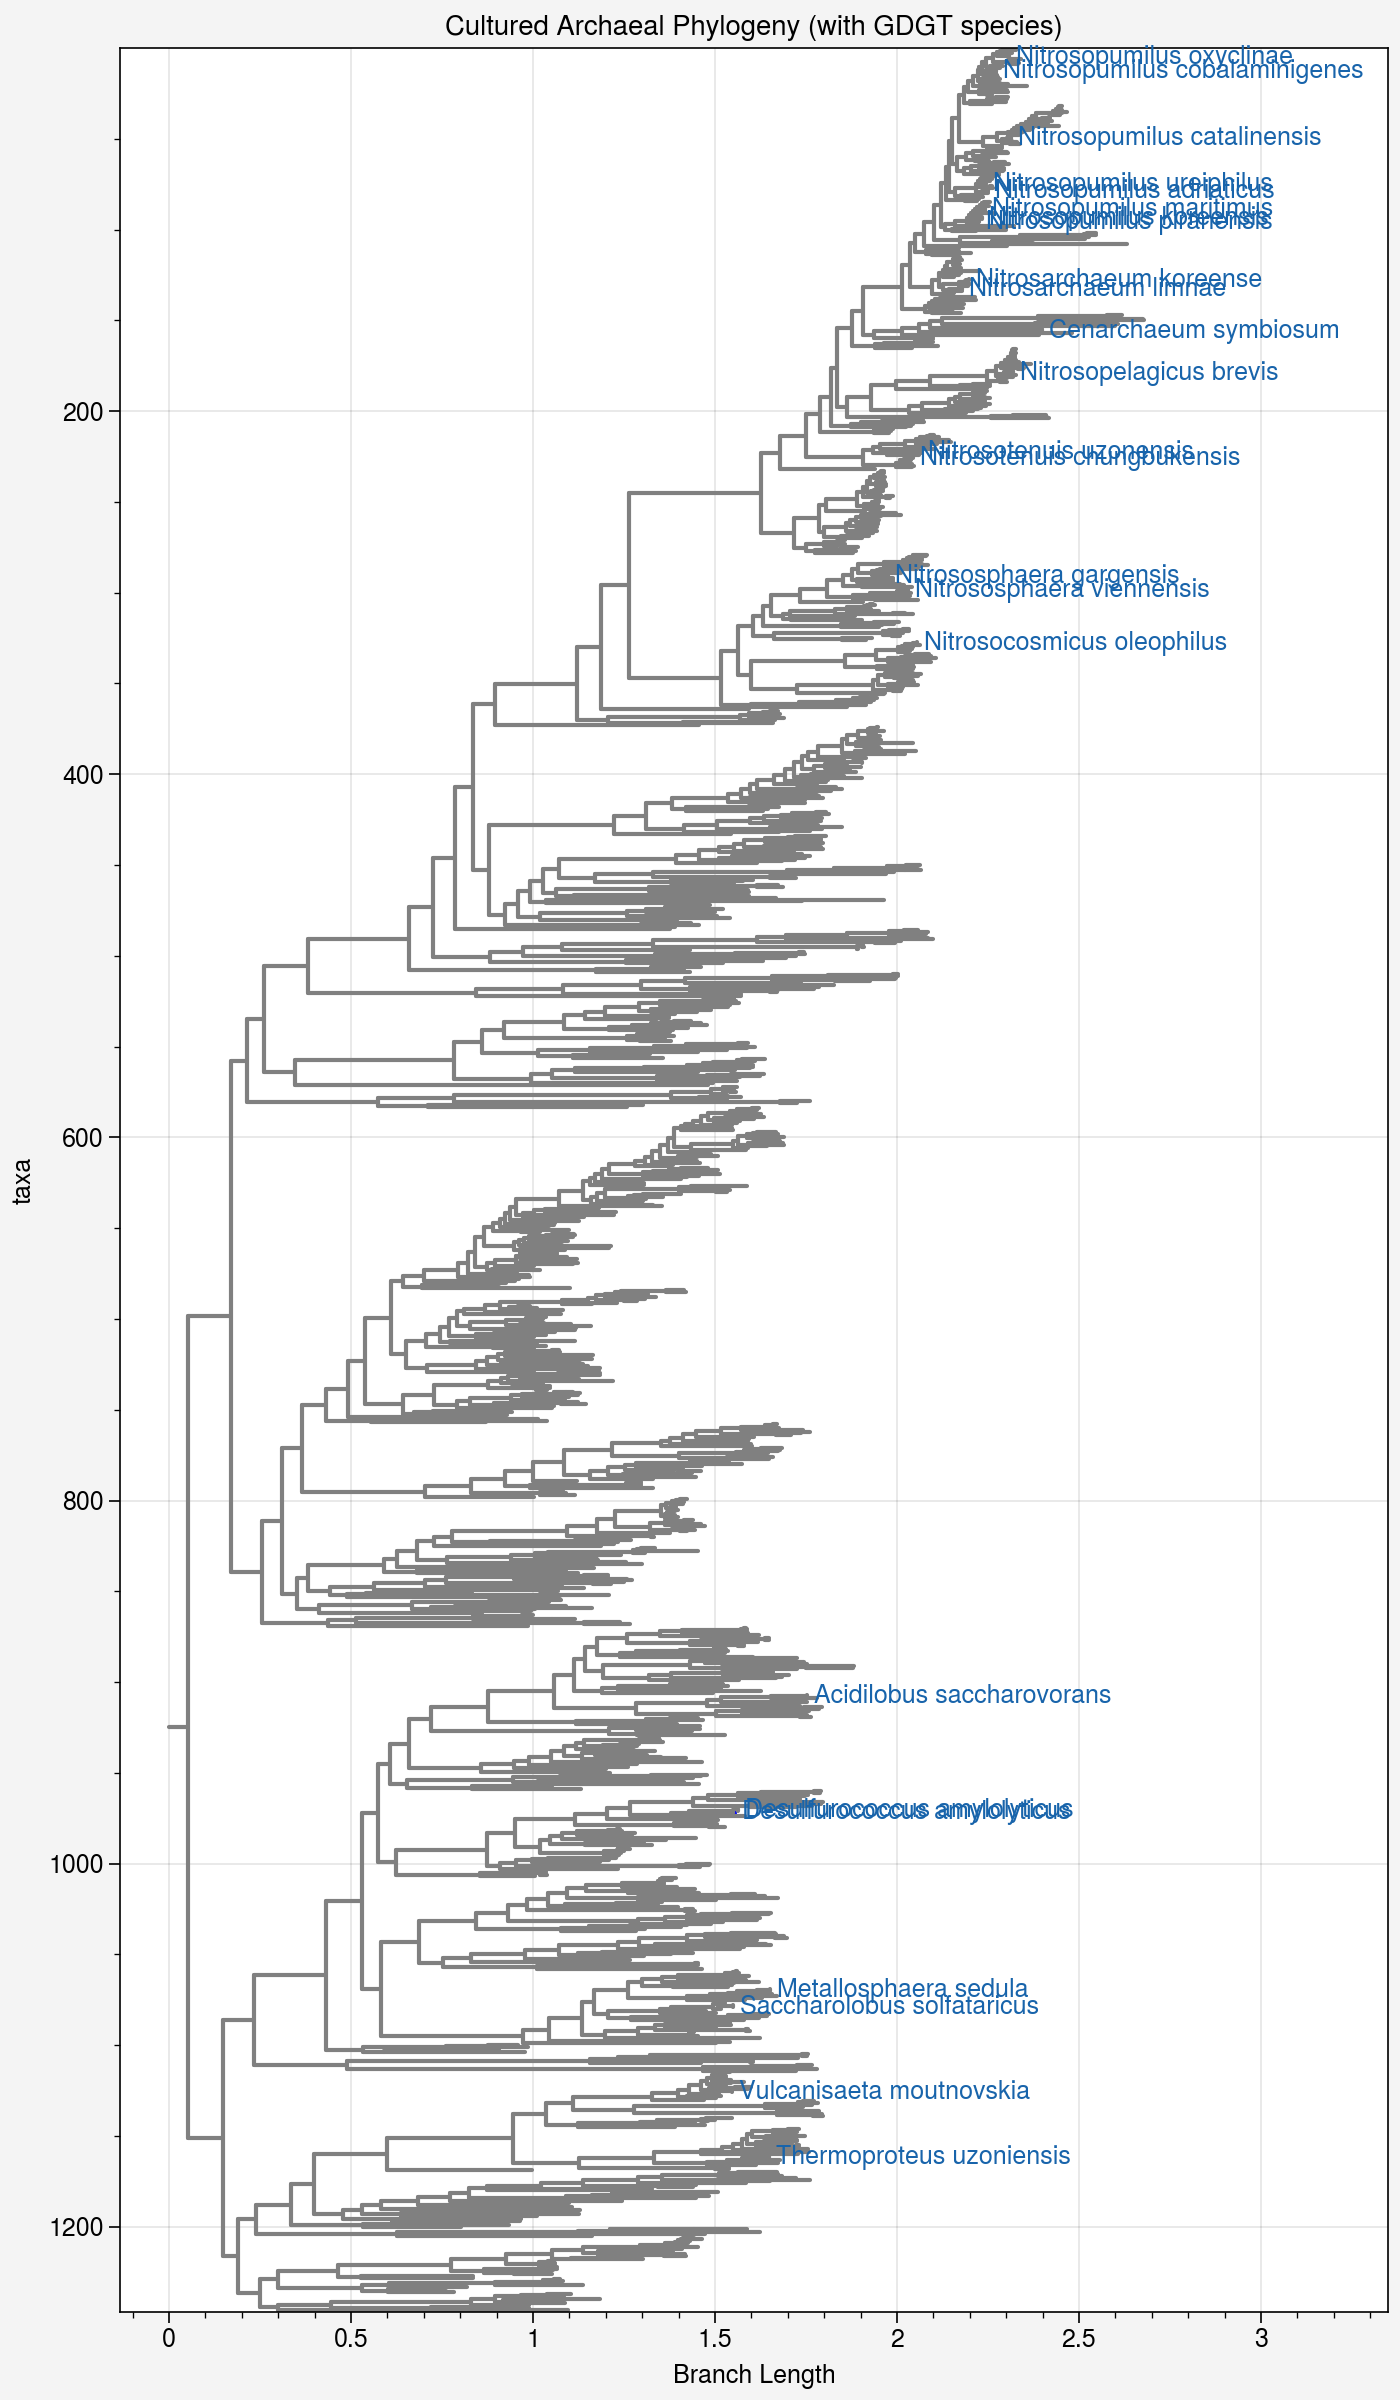

In [15]:
from Bio import Phylo
import matplotlib.pyplot as plt
from pathlib import Path

# ===================================================================
# --- 1. SETUP & DATA LOADING ---
# ===================================================================

# Paths
# local_github_path = "..." # Make sure this is defined
tree_file = f"{local_github_path}/data/phylo/trees/texas_genome_phylogenetic.tree"
species_file = f"{local_github_path}/data/phylo/texas_genome_species_list.txt"

# Helper functions (your functions are good, no changes needed)
def norm_acc(x: str) -> str:
    x = x.strip()
    if x.startswith("user_"):
        x = x[5:]
    return x

def variants(acc: str):
    base = norm_acc(acc)
    base_novers = base.split('.')[0]
    return {base, f"user_{base}", base_novers, f"user_{base_novers}"}

# Load species mapping (accession -> name)
mapping = {}
with open(species_file) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        left, right = line.split("->", 1)
        acc = left.strip()
        name = right.strip()
        for v in variants(acc):
            mapping[v] = name

# --- Read the full tree ---
tree = Phylo.read(tree_file, "newick")


# ===================================================================
# --- 2. TREE MANIPULATION (FINAL VERSION w/ STRATEGIC PRUNING) ---
# ===================================================================

# --- Relabel the tree tips first ---
# (Your relabeling code here is correct)
for cl in tree.get_terminals():
    if cl.name in mapping:
        cl.name = mapping[cl.name]

# --- Create the target set from the final species names ---
species_with_gdgt = set(mapping.values())

# --- Prune the tree to the main group of interest (Robust Method) ---

print("Finding the smallest clade containing all target species...")

# 0. Get the actual tree objects for your species
target_clades = [cl for cl in tree.get_terminals() if cl.name in species_with_gdgt]

# Safety check (still good practice)
if not target_clades:
    raise ValueError("Could not find any target species in the tree.")

# Assuming 'tree' and 'target_clades' (the list of your strain objects) are already defined

# --- Create the "Zoomed-In" Plot for the Main Cluster ---

# 1. Create a new set of target species that EXCLUDES the outlier
main_cluster_species = species_with_gdgt.copy()  # Make a copy to work with
main_cluster_species.remove('Picrophilus oshimae')

# 2. Find the MRCA of *just* this main group from the ORIGINAL full tree
main_cluster_clades = [cl for cl in tree.get_terminals() if cl.name in main_cluster_species]
main_cluster_mrca = tree.common_ancestor(main_cluster_clades)

print(f"Focused tree on the ancestor {levels_up} level(s) up from the MRCA.")
# ===================================================================
# --- 3. PLOTTING ---
# ===================================================================

# ## REFINEMENT 1: Set branch colors before plotting ##
# Set branch colors for high contrast
for clade in main_cluster_mrca.find_clades():
    if clade.is_terminal() and (clade.name in species_with_gdgt):
        clade.color = 'blue'  # Make the final branch to your species blue
    else:
        clade.color = 'gray' # Make all other branches a light grey

# This function will decide what label to show for each tip
def selective_label(clade):
    if clade.name in species_with_gdgt:
        return f"  {clade.name}"
    return ""

# --- Prepare for plotting ---
# ## REFINEMENT: Make the figure taller to give labels more space
fig, axs = plot.subplots(figsize=(7, 12))

ax_tree = axs[0]
main_cluster_mrca.ladderize(True)

# Use our new function to only draw the labels we want
Phylo.draw(
    main_cluster_mrca,
    axes=ax_tree,
    do_show=False,
    label_colors=lambda name: 'blue9' if name.strip() in species_with_gdgt else 'gray5',
    label_func=lambda c: c.name if c.name in main_cluster_species else '',
    show_confidence=None,
)


for txt in ax_tree.texts:
    # We check if the text is a number (a bootstrap value)
    try:
        # This will succeed if the text is a number like '100' or '96.0'
        # and fail if it's a species name.
        if 0 <= float(txt.get_text()) <= 100:
            txt.set_fontsize(4)
            txt.set_color('gray7')
    except (ValueError, TypeError):
        # This text is not a number, so we ignore it.
        continue

ax_tree.set_title("Cultured Archaeal Phylogeny (with GDGT species)")
ax_tree.set_xlabel("Branch Length")

Found 15 species in the 'Nitrosopumilus' cluster.
Tree terminal species:
  0: 'GB_GCA_905479565.1'
  1: 'GB_GCA_030637455.1'
  2: 'GB_GCA_029782475.1'
  3: 'RS_GCF_013407165.1'
  4: 'Nitrosopumilus oxyclinae'
  5: 'GB_GCA_029255365.1'
  6: 'GB_GCA_013203245.1'
  7: 'GB_GCA_937875805.1'
  8: 'GB_GCA_029250275.1'
  9: 'GB_GCA_024276695.1'
  10: 'GB_GCA_014384555.1'
  11: 'RS_GCF_013407145.1'
  12: 'Nitrosopumilus cobalaminigenes'
  13: 'GB_GCA_024644105.1'
  14: 'GB_GCA_013043295.1'
  15: 'RS_GCF_000299395.1'
  16: 'RS_GCF_029882185.1'
  17: 'GB_GCA_025699075.1'
  18: 'RS_GCF_025699255.1'
  19: 'GB_GCA_951812645.1'
  20: 'GB_GCA_002506665.1'
  21: 'GB_GCA_014075315.1'
  22: 'GB_GCA_029263475.1'
  23: 'GB_GCA_951812655.1'
  24: 'GB_GCA_029861085.1'
  25: 'GB_GCA_029860565.1'
  26: 'GB_GCA_029880665.1'
  27: 'GB_GCA_020431995.1'
  28: 'GB_GCA_029862745.1'
  29: 'RS_GCF_000242875.2'
  30: 'GB_GCA_002788515.1'
  31: 'GB_GCA_028335865.1'
  32: 'GB_GCA_028439825.1'
  33: 'GB_GCA_028351415.1'
 

NameError: name 'x_max' is not defined

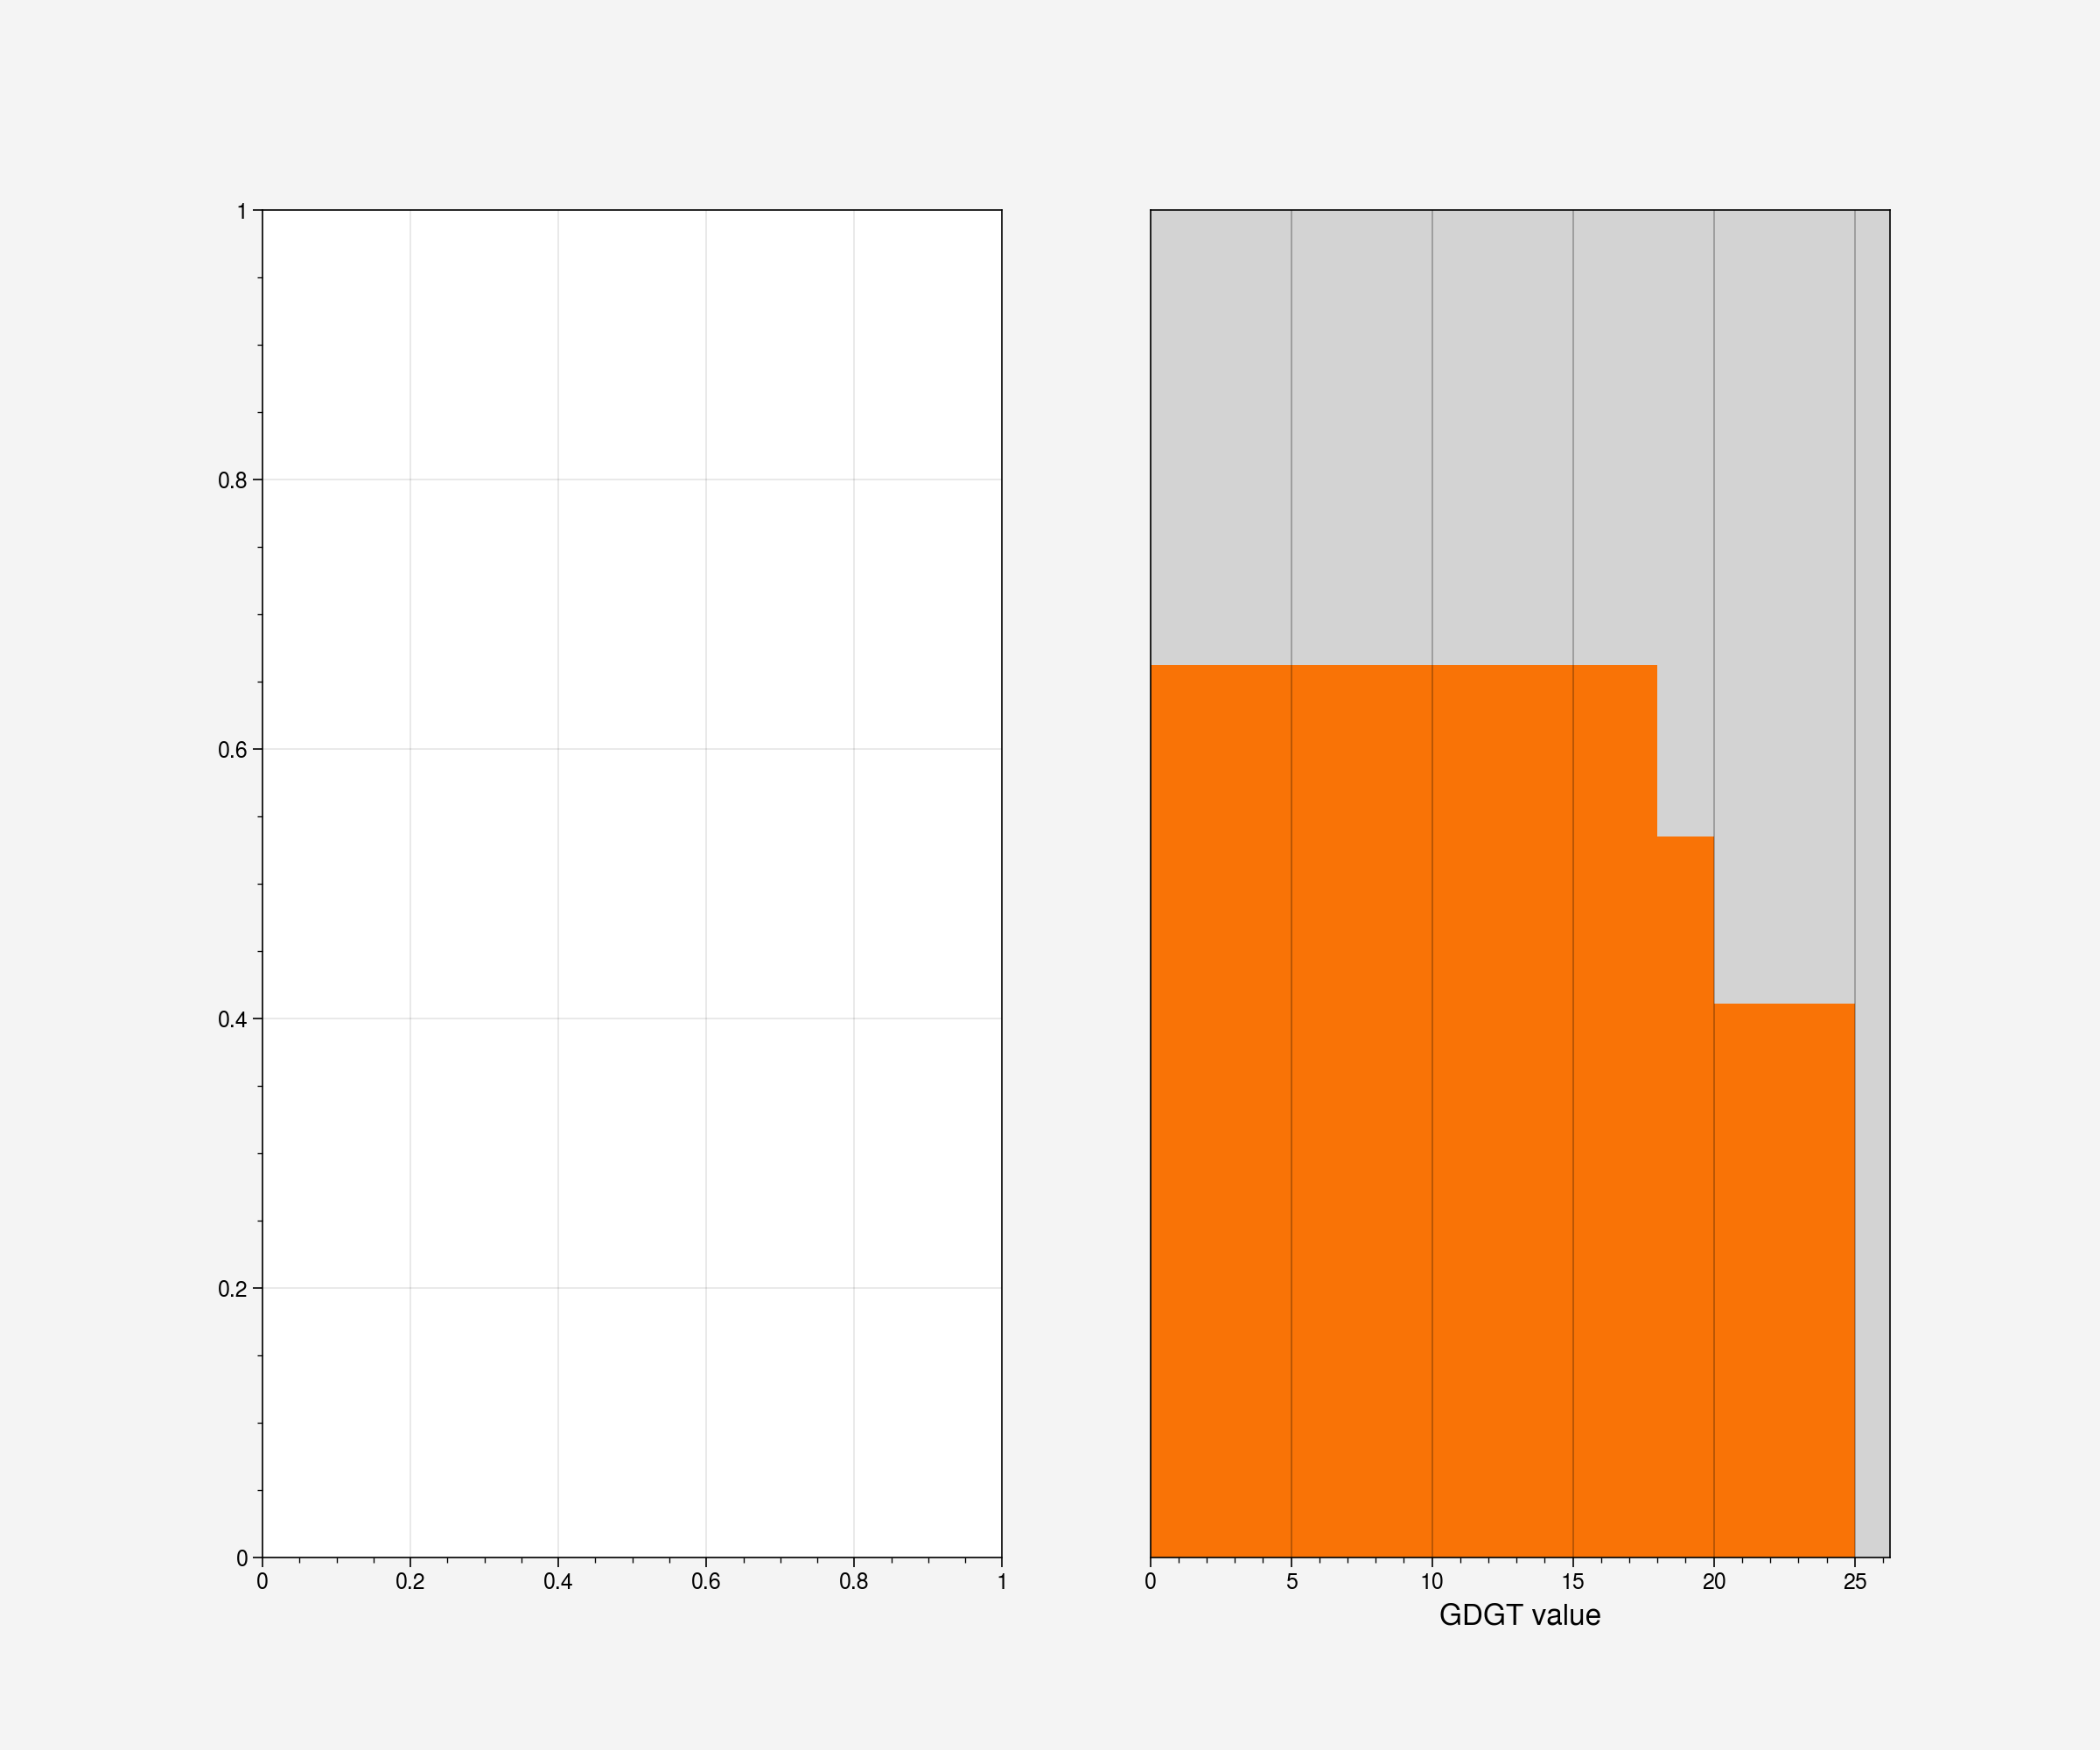

In [16]:
from Bio import Phylo
import matplotlib.pyplot as plt
from pathlib import Path

# ===================================================================
# --- 1. SETUP & DATA LOADING ---
# ===================================================================

# Paths
# local_github_path = "..." # Make sure this is defined
tree_file = f"{local_github_path}/data/phylo/trees/texas_genome_phylogenetic.tree"
species_file = f"{local_github_path}/data/phylo/texas_genome_species_list.txt"

# Helper functions (your functions are good, no changes needed)
def norm_acc(x: str) -> str:
    x = x.strip()
    if x.startswith("user_"):
        x = x[5:]
    return x

def variants(acc: str):
    base = norm_acc(acc)
    base_novers = base.split('.')[0]
    return {base, f"user_{base}", base_novers, f"user_{base_novers}"}

# Load species mapping (accession -> name)
mapping = {}
with open(species_file) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        left, right = line.split("->", 1)
        acc = left.strip()
        name = right.strip()
        for v in variants(acc):
            mapping[v] = name

# --- Read the full tree ---
tree = Phylo.read(tree_file, "newick")


# ===================================================================
# --- 2. TREE MANIPULATION (FINAL VERSION w/ STRATEGIC PRUNING) ---
# ===================================================================

# --- Relabel the tree tips first ---
# (Your relabeling code here is correct)
for cl in tree.get_terminals():
    if cl.name in mapping:
        cl.name = mapping[cl.name]

# --- Create the target set from the final species names ---
species_with_gdgt = set(mapping.values())

# Assuming 'tree' is the original, full tree object, and
# 'species_with_gdgt' is your full set of 25 strain names.

# 1. Define the new, more specific target group.
target_genera = ('Nitrosopumilus','Cenarchaeum','Nitrosopelagicus',
                 'Nitrosotenuis','Nitrososphaera','Nitrosocosmicus')
nitros_cluster_species = {
    name for name in species_with_gdgt if name.startswith(target_genera)
}

print(f"Found {len(nitros_cluster_species)} species in the 'Nitrosopumilus' cluster.")

# 2. Find the MRCA of this specific group within the full tree.
nitros_cluster_clades = [
    cl for cl in tree.get_terminals() if cl.name in nitros_cluster_species
]

# A safety check is always good practice.
if not nitros_cluster_clades:
    raise ValueError("Could not find any species for the specified cluster in the tree.")

nitros_cluster_mrca = tree.common_ancestor(nitros_cluster_clades)

# 3. This MRCA is your new, more focused tree for plotting.
focused_tree = nitros_cluster_mrca
focused_tree.ladderize(True)

############################################################################
############################################################################
############################################################################
############################################################################
# ===================================================================
# --- 3. PLOTTING ---
# ===================================================================

fig, axs = plt.subplots(ncols=2, figsize=(12, 10), sharex=False)

ax_tree = axs[0] # Assign the first subplot to ax_tree for clarity
ax_bars = axs[1] # Assign the second subplot to ax_bars for clarity

# --- Prepare GDGT data and align with tree labels ---

# Sample GDGT data (adjust with your actual data)
gdgt_data = {
    'Nitrosopumilus maritimus': 10,
    'Nitrosopumilus oxyclinae': 25,
    'Nitrosopumilus ureiphilus': 15,
    'Nitrosopumilus catalinensis': 20,
    'Nitrosopumilus adriaticus': 12,
    'Nitrosopumilus piranensis': 18,
    # Add more data for your species here
}

# Get the terminal nodes after drawing
terminals = focused_tree.get_terminals()

# Print species names for debugging
print("Tree terminal species:")
for i, terminal in enumerate(terminals):
    print(f"  {i}: '{terminal.name}'")

print("\nGDGT data species:")
for name in gdgt_data.keys():
    print(f"  '{name}'")

# After Phylo.draw(), we need to get the actual y-coordinates from matplotlib
# The tree plot uses a coordinate system where each terminal gets a y-value
# We can get these by looking at the current tick positions or calculating them

# Get the y-limits that were set by the tree plot
y_min, y_max = ax_tree.get_ylim()
n_terminals = len(terminals)

# Create a mapping from species name to y-coordinate
# The terminals are plotted at evenly spaced y-coordinates
y_coords_map = {}

# Method 1: Try to get tick positions if they exist
yticks = ax_tree.get_yticks()
if len(yticks) == len(terminals):
    for terminal, y_pos in zip(terminals, yticks):
        y_coords_map[terminal.name] = y_pos
else:
    # Method 2: Calculate evenly spaced positions
    if n_terminals > 1:
        y_positions = [y_min + i * (y_max - y_min) / (n_terminals - 1) for i in range(n_terminals)]
    else:
        y_positions = [(y_min + y_max) / 2]
    
    for terminal, y_pos in zip(terminals, y_positions):
        y_coords_map[terminal.name] = y_pos

print(f"\nY-coordinate mapping:")
for name, y in y_coords_map.items():
    print(f"  '{name}': {y}")

# Prepare data for bar chart
ys, vals, labels = [], [], []
for name, val in gdgt_data.items():
    if name in y_coords_map:
        ys.append(y_coords_map[name])
        vals.append(val)
        labels.append(name)
        print(f"Matched: '{name}' -> y={y_coords_map[name]}, val={val}")

print(f"\nFound {len(ys)} matches for bar chart")

# Draw bars on the right axis
if ys and vals:  # Only plot if we have data
    # Debug: show the ranges
    print(f"Y range: {min(ys)} to {max(ys)}")
    print(f"X range: 0 to {max(vals)}")
    print(f"Tree y-limits: {ax_tree.get_ylim()}")
    
    # Draw the bars with a more appropriate height
    bars = ax_bars.barh(ys, vals, color='orange',)
    
    # Make the y-range match the tree exactly
    tree_ylims = ax_tree.get_ylim()
    ax_bars.set_ylim(tree_ylims)
    print(f"Set bar chart y-limits to: {ax_bars.get_ylim()}")
    
    # Check if tree y-axis is inverted and match it
    if ax_tree.yaxis_inverted():
        ax_bars.invert_yaxis()
        print("Inverted bar chart y-axis to match tree")
    
    # Ensure bars are visible on x with some padding

    
    # Add some padding and formatting
    ax_bars.set_xlabel("GDGT value", fontsize=12)
    ax_bars.grid(True, alpha=0.3, axis='x')
    
    # Remove y-tick labels on the bar chart
    ax_bars.set_yticks([])
    
    # Force a redraw
    ax_bars.set_facecolor('lightgray')  # Temp background to see if axis is working
    
    print(f"Successfully plotted {len(vals)} bars")
    print(f"Bar positions (y): {ys}")
    print(f"Bar lengths (x): {vals}")
    
    # Add text labels for debugging
    for i, (y, val) in enumerate(zip(ys, vals)):
        ax_bars.text(val + x_max*0.02, y, f'{val}', va='center', fontsize=8, color='red')
        
else:
    print("ERROR: No matching species found between tree and GDGT data")
    ax_bars.text(0.5, 0.5, 'No data to plot', transform=ax_bars.transAxes, 
                ha='center', va='center', fontsize=12, color='red')
    
# Plot the tree on the first subplot
Phylo.draw(focused_tree,
           axes=ax_tree,
           label_func=lambda c: c.name if c.name in species_with_gdgt else '',
           label_colors=lambda name: 'blue' if name.strip() in species_with_gdgt else 'gray',
           show_confidence=False
           )
ax_tree.set_title("Focused View of the Nitrosopumilus Clade")

fig.tight_layout()
plt.show()  # FIXED: was fig.show()

Found 15 species in the 'Nitrosopumilus' cluster.
Tree species order (first 10): ['GB_GCA_905479565.1', 'GB_GCA_030637455.1', 'GB_GCA_029782475.1', 'RS_GCF_013407165.1', 'Nitrosopumilus oxyclinae', 'GB_GCA_029255365.1', 'GB_GCA_013203245.1', 'GB_GCA_937875805.1', 'GB_GCA_029250275.1', 'GB_GCA_024276695.1']
Found GDGT data for 8 species:
  Position 4: Nitrosopumilus oxyclinae = 25
  Position 49: Nitrosopumilus catalinensis = 20
  Position 74: Nitrosopumilus ureiphilus = 15
  Position 78: Nitrosopumilus adriaticus = 12
  Position 88: Nitrosopumilus maritimus = 10
  Position 95: Nitrosopumilus piranensis = 18
  Position 127: Nitrosarchaeum koreense = 8
  Position 155: Cenarchaeum symbiosum = 22
Tree y-limits: (0.0, 1.0)
Tree has 363 species
Aligned y-coordinates: [0.011049723756906077, 0.13535911602209943, 0.20441988950276244, 0.2154696132596685, 0.2430939226519337, 0.26243093922651933, 0.35082872928176795, 0.4281767955801105]


AttributeError: 'tuple' object has no attribute 'min'

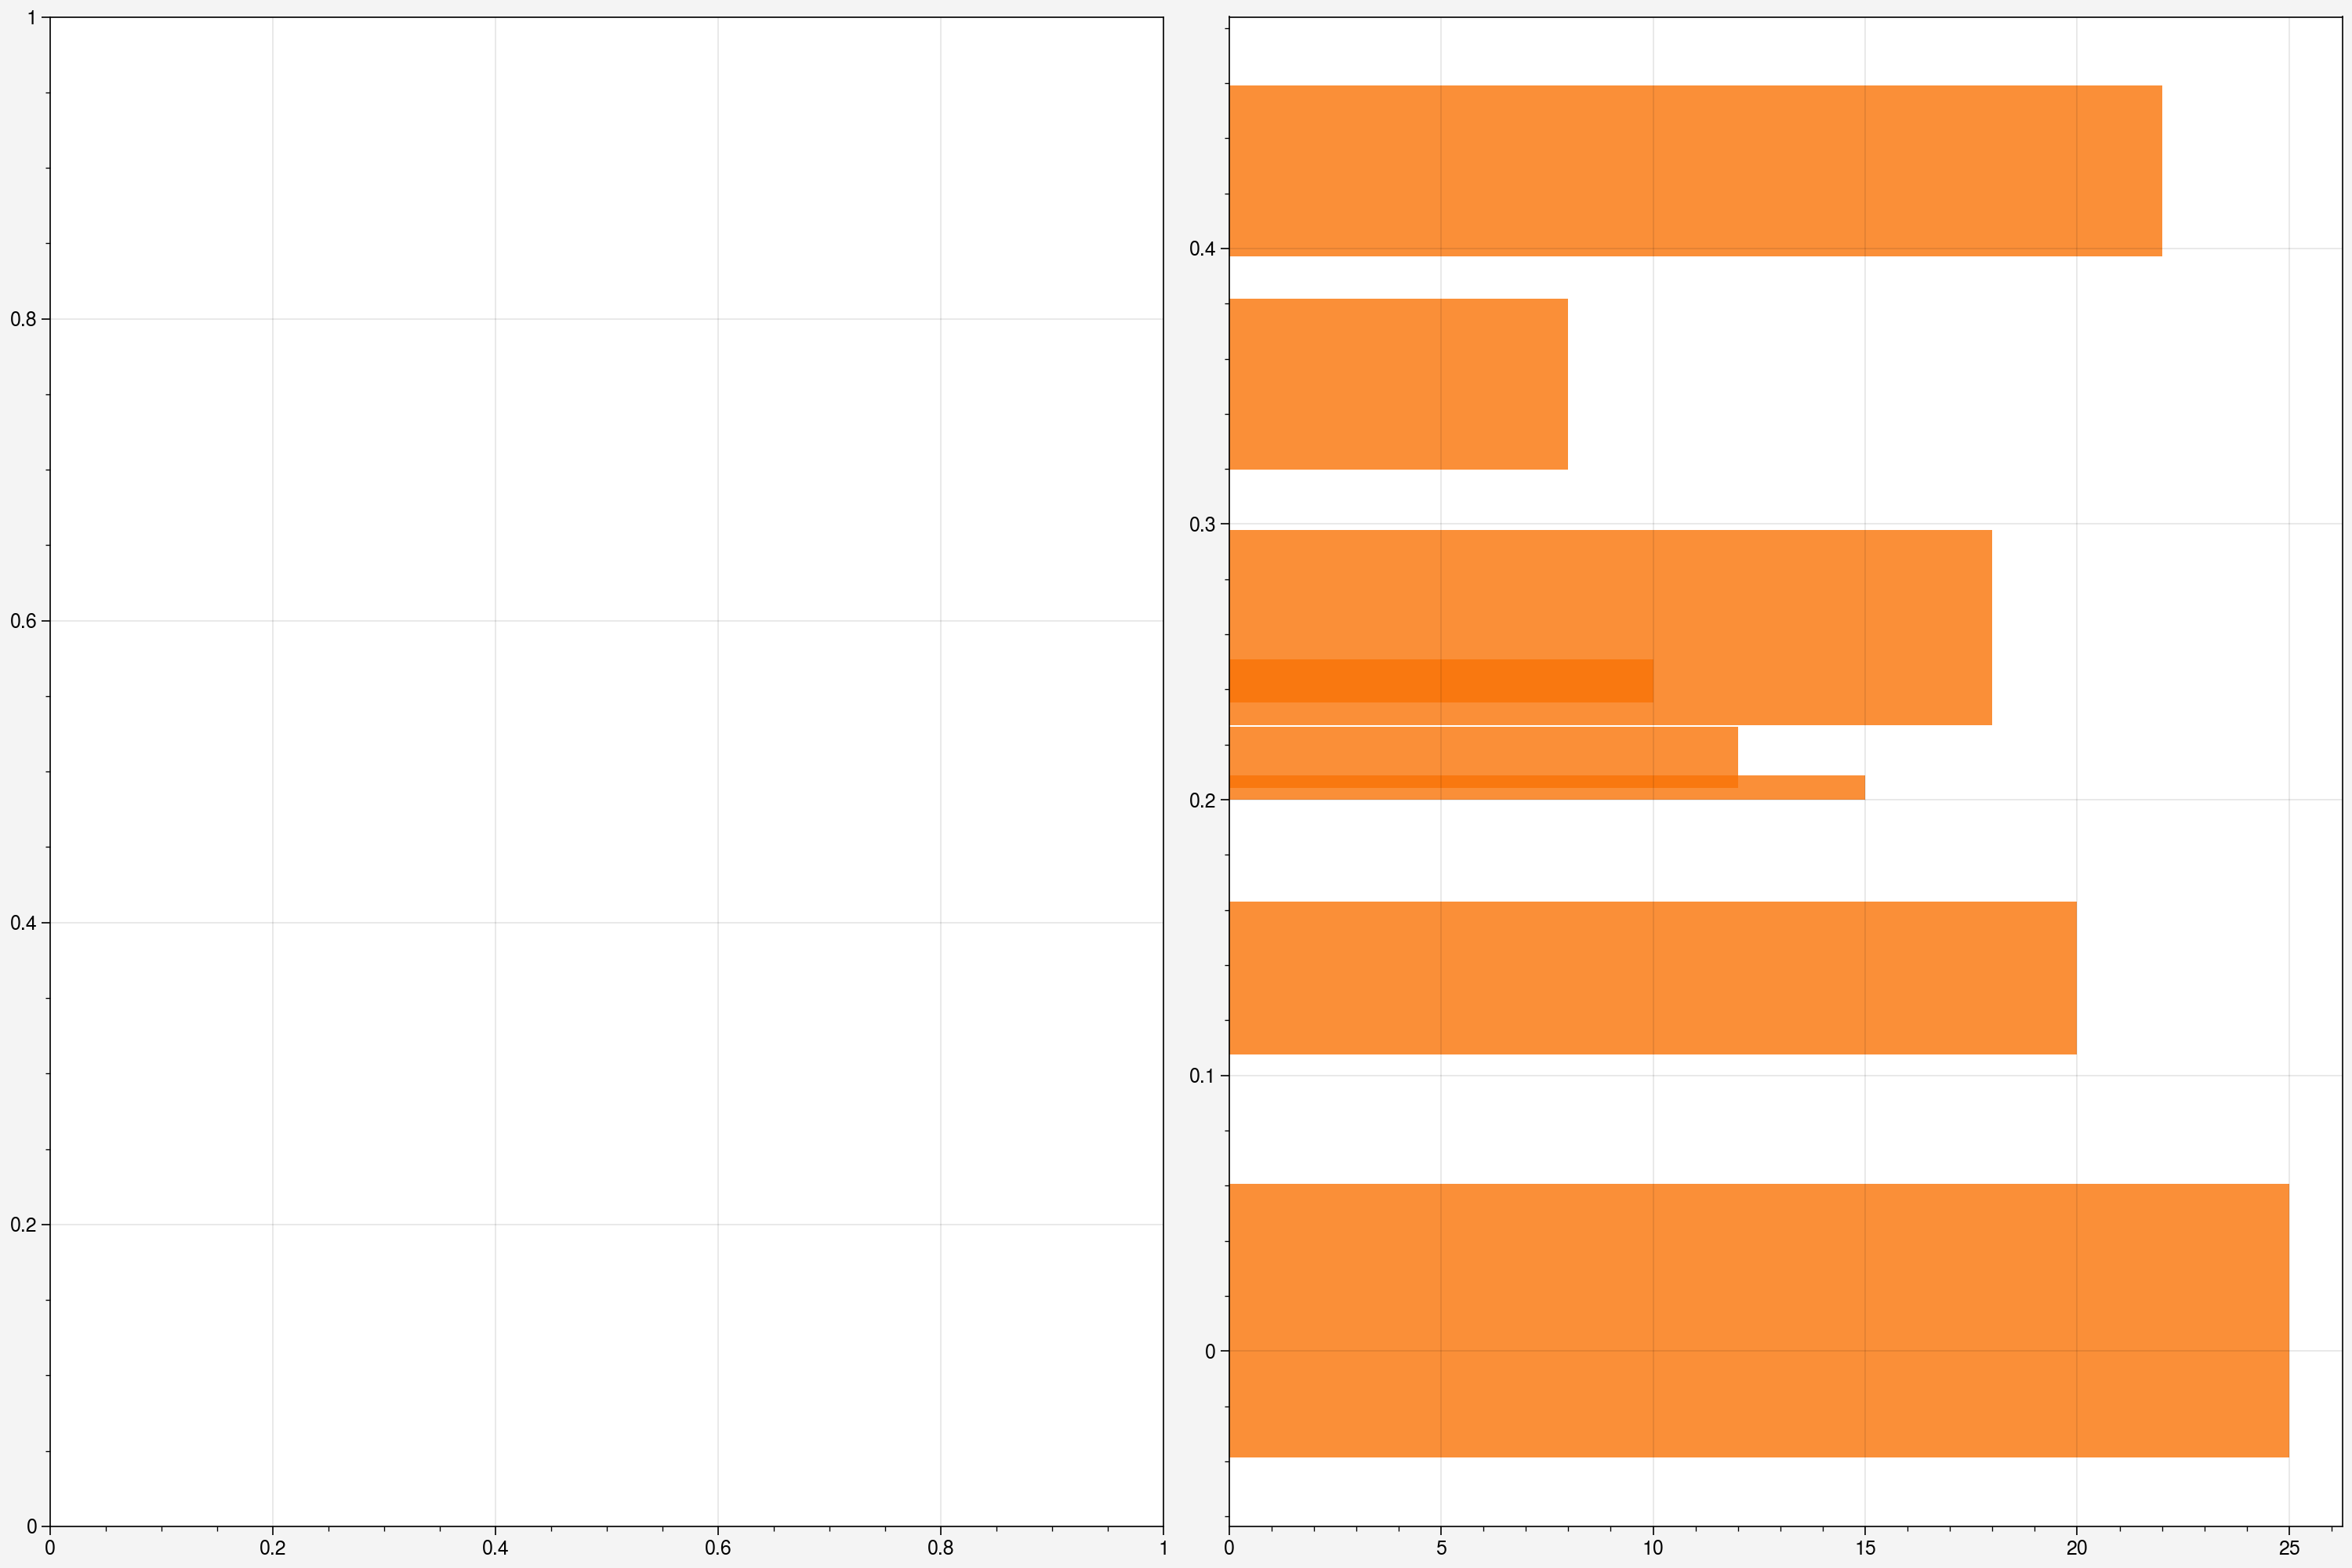

In [ ]:
from Bio import Phylo
import matplotlib.pyplot as plt
from pathlib import Path

# ===================================================================
# --- 1. SETUP & DATA LOADING (same as before) ---
# ===================================================================

# Paths
# local_github_path = "..." # Make sure this is defined
tree_file = f"{local_github_path}/data/phylo/trees/texas_genome_phylogenetic.tree"
species_file = f"{local_github_path}/data/phylo/texas_genome_species_list.txt"

# Helper functions
def norm_acc(x: str) -> str:
    x = x.strip()
    if x.startswith("user_"):
        x = x[5:]
    return x

def variants(acc: str):
    base = norm_acc(acc)
    base_novers = base.split('.')[0]
    return {base, f"user_{base}", base_novers, f"user_{base_novers}"}

# Load species mapping (accession -> name)
mapping = {}
with open(species_file) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        left, right = line.split("->", 1)
        acc = left.strip()
        name = right.strip()
        for v in variants(acc):
            mapping[v] = name

# Read the full tree
tree = Phylo.read(tree_file, "newick")

# ===================================================================
# --- 2. TREE MANIPULATION (same as before) ---
# ===================================================================

# Relabel the tree tips first
for cl in tree.get_terminals():
    if cl.name in mapping:
        cl.name = mapping[cl.name]

# Create the target set from the final species names
species_with_gdgt = set(mapping.values())

# Define the target group
target_genera = ('Nitrosopumilus','Cenarchaeum','Nitrosopelagicus',
                 'Nitrosotenuis','Nitrososphaera','Nitrosocosmicus')
nitros_cluster_species = {
    name for name in species_with_gdgt if name.startswith(target_genera)
}

print(f"Found {len(nitros_cluster_species)} species in the 'Nitrosopumilus' cluster.")

# Find the MRCA of this specific group within the full tree
nitros_cluster_clades = [
    cl for cl in tree.get_terminals() if cl.name in nitros_cluster_species
]

if not nitros_cluster_clades:
    raise ValueError("Could not find any species for the specified cluster in the tree.")

nitros_cluster_mrca = tree.common_ancestor(nitros_cluster_clades)

# This MRCA is your new, more focused tree for plotting
focused_tree = nitros_cluster_mrca
focused_tree.ladderize(True)

# ===================================================================
# --- 3. FIXED COORDINATE ALIGNMENT APPROACH ---
# ===================================================================

# Create the two-panel figure
fig, (ax_tree, ax_bars) = plot.subplots(ncols=2, figsize=(15, 10),share=0)

# STEP 2: Extract species order from tree (top to bottom as they appear)
terminals = focused_tree.get_terminals()
tree_species_order = [term.name for term in terminals]

print(f"Tree species order (first 10): {tree_species_order[:10]}")

# STEP 3: GDGT data 
gdgt_data = {
    'Nitrosopumilus maritimus': 10,
    'Nitrosopumilus oxyclinae': 25,
    'Nitrosopumilus ureiphilus': 15,
    'Nitrosopumilus catalinensis': 20,
    'Nitrosopumilus adriaticus': 12,
    'Nitrosopumilus piranensis': 18,
    'Nitrosarchaeum koreense': 8,
    'Cenarchaeum symbiosum': 22,
    # Add more data as needed
}

# STEP 4: Create aligned bar chart using INTEGER positions
# Map each species to its position in the tree order
bar_positions = []
bar_values = []
bar_labels = []

for i, species_name in enumerate(tree_species_order):
    if species_name in gdgt_data:
        bar_positions.append(i)  # Use integer position in tree order
        bar_values.append(gdgt_data[species_name])
        bar_labels.append(species_name)

print(f"Found GDGT data for {len(bar_values)} species:")
for pos, label, val in zip(bar_positions, bar_labels, bar_values):
    print(f"  Position {pos}: {label} = {val}")

# STEP 5: Plot bars using the tree coordinate system
if bar_positions and bar_values:
    # Get the tree's y-axis limits to match coordinate systems
    tree_ylim = ax_tree.get_ylim()
    n_species = len(tree_species_order)
    
    print(f"Tree y-limits: {tree_ylim}")
    print(f"Tree has {n_species} species")
    
    # Calculate where each species appears in tree coordinate space
    # Since tree species are positioned from top to bottom in tree_ylim range
    if tree_ylim[0] > tree_ylim[1]:  # y-axis is inverted
        y_max, y_min = tree_ylim
        tree_inverted = True
    else:
        y_min, y_max = tree_ylim
        tree_inverted = False
    
    # Map integer positions to tree coordinate space
    aligned_positions = []
    for pos in bar_positions:
        if n_species > 1:
            # Linear interpolation from tree coordinate space
            if tree_inverted:
                y_coord = y_max + (pos * (y_min - y_max) / (n_species - 1))
            else:
                y_coord = y_min + (pos * (y_max - y_min) / (n_species - 1))
        else:
            y_coord = (y_min + y_max) / 2
        aligned_positions.append(y_coord)
    
    print(f"Aligned y-coordinates: {aligned_positions}")
    
    # Plot bars with aligned coordinates
    bars = ax_bars.barh(aligned_positions, bar_values, color='orange', alpha=0.8, 
                       height=abs(y_max - y_min) / n_species * 0.6)
    
    # Match the tree's y-axis exactly
    # ax_bars.set_ylim(tree_ylim)
    ax_bars.format(
        ylim=(tree_ylim.min(),tree_ylim.maxs()),yreverse=tree_inverted)
    
    # Set x-axis with some padding
    max_val = max(bar_values)
    ax_bars.set_xlim(0, max_val * 1.2)
    
    # Add value labels to bars
    for y_coord, val in zip(aligned_positions, bar_values):
        ax_bars.text(val + max_val * 0.02, y_coord, f'{val}', 
                    va='center', ha='left', fontsize=10, color='black')
    
    # Formatting
    ax_bars.set_xlabel('GDGT Value', fontsize=12)
    ax_bars.set_title('GDGT Measurements', fontsize=14, pad=20)
    ax_bars.grid(True, alpha=0.3, axis='x')
    ax_bars.set_yticks([])  # Remove y-tick labels to avoid confusion
    
    print(f"Successfully plotted {len(bar_values)} aligned bars")
    
else:
    ax_bars.text(0.5, 0.5, 'No matching GDGT data found', 
                transform=ax_bars.transAxes, ha='center', va='center',
                fontsize=12, color='red')
    print("No matching GDGT data found")

# STEP 1: Plot the tree on the left panel (this works fine)
Phylo.draw(focused_tree,
           axes=ax_tree,
           label_func=lambda c: c.name if c.name in species_with_gdgt else '',
           label_colors=lambda name: 'blue' if name.strip() in species_with_gdgt else 'gray',
           show_confidence=False)
ax_tree.set_title("Focused View of the Nitrosopumilus Clade", fontsize=14, pad=20)

# Final layout adjustment
plt.tight_layout()
plt.show()

print("\nAlignment summary:")
print(f"- Tree coordinate range: {ax_tree.get_ylim()}")
print(f"- Bar coordinate range: {ax_bars.get_ylim()}")
print(f"- Coordinate systems aligned: {ax_tree.get_ylim() == ax_bars.get_ylim()}")

Extracting species positions from tree layout...


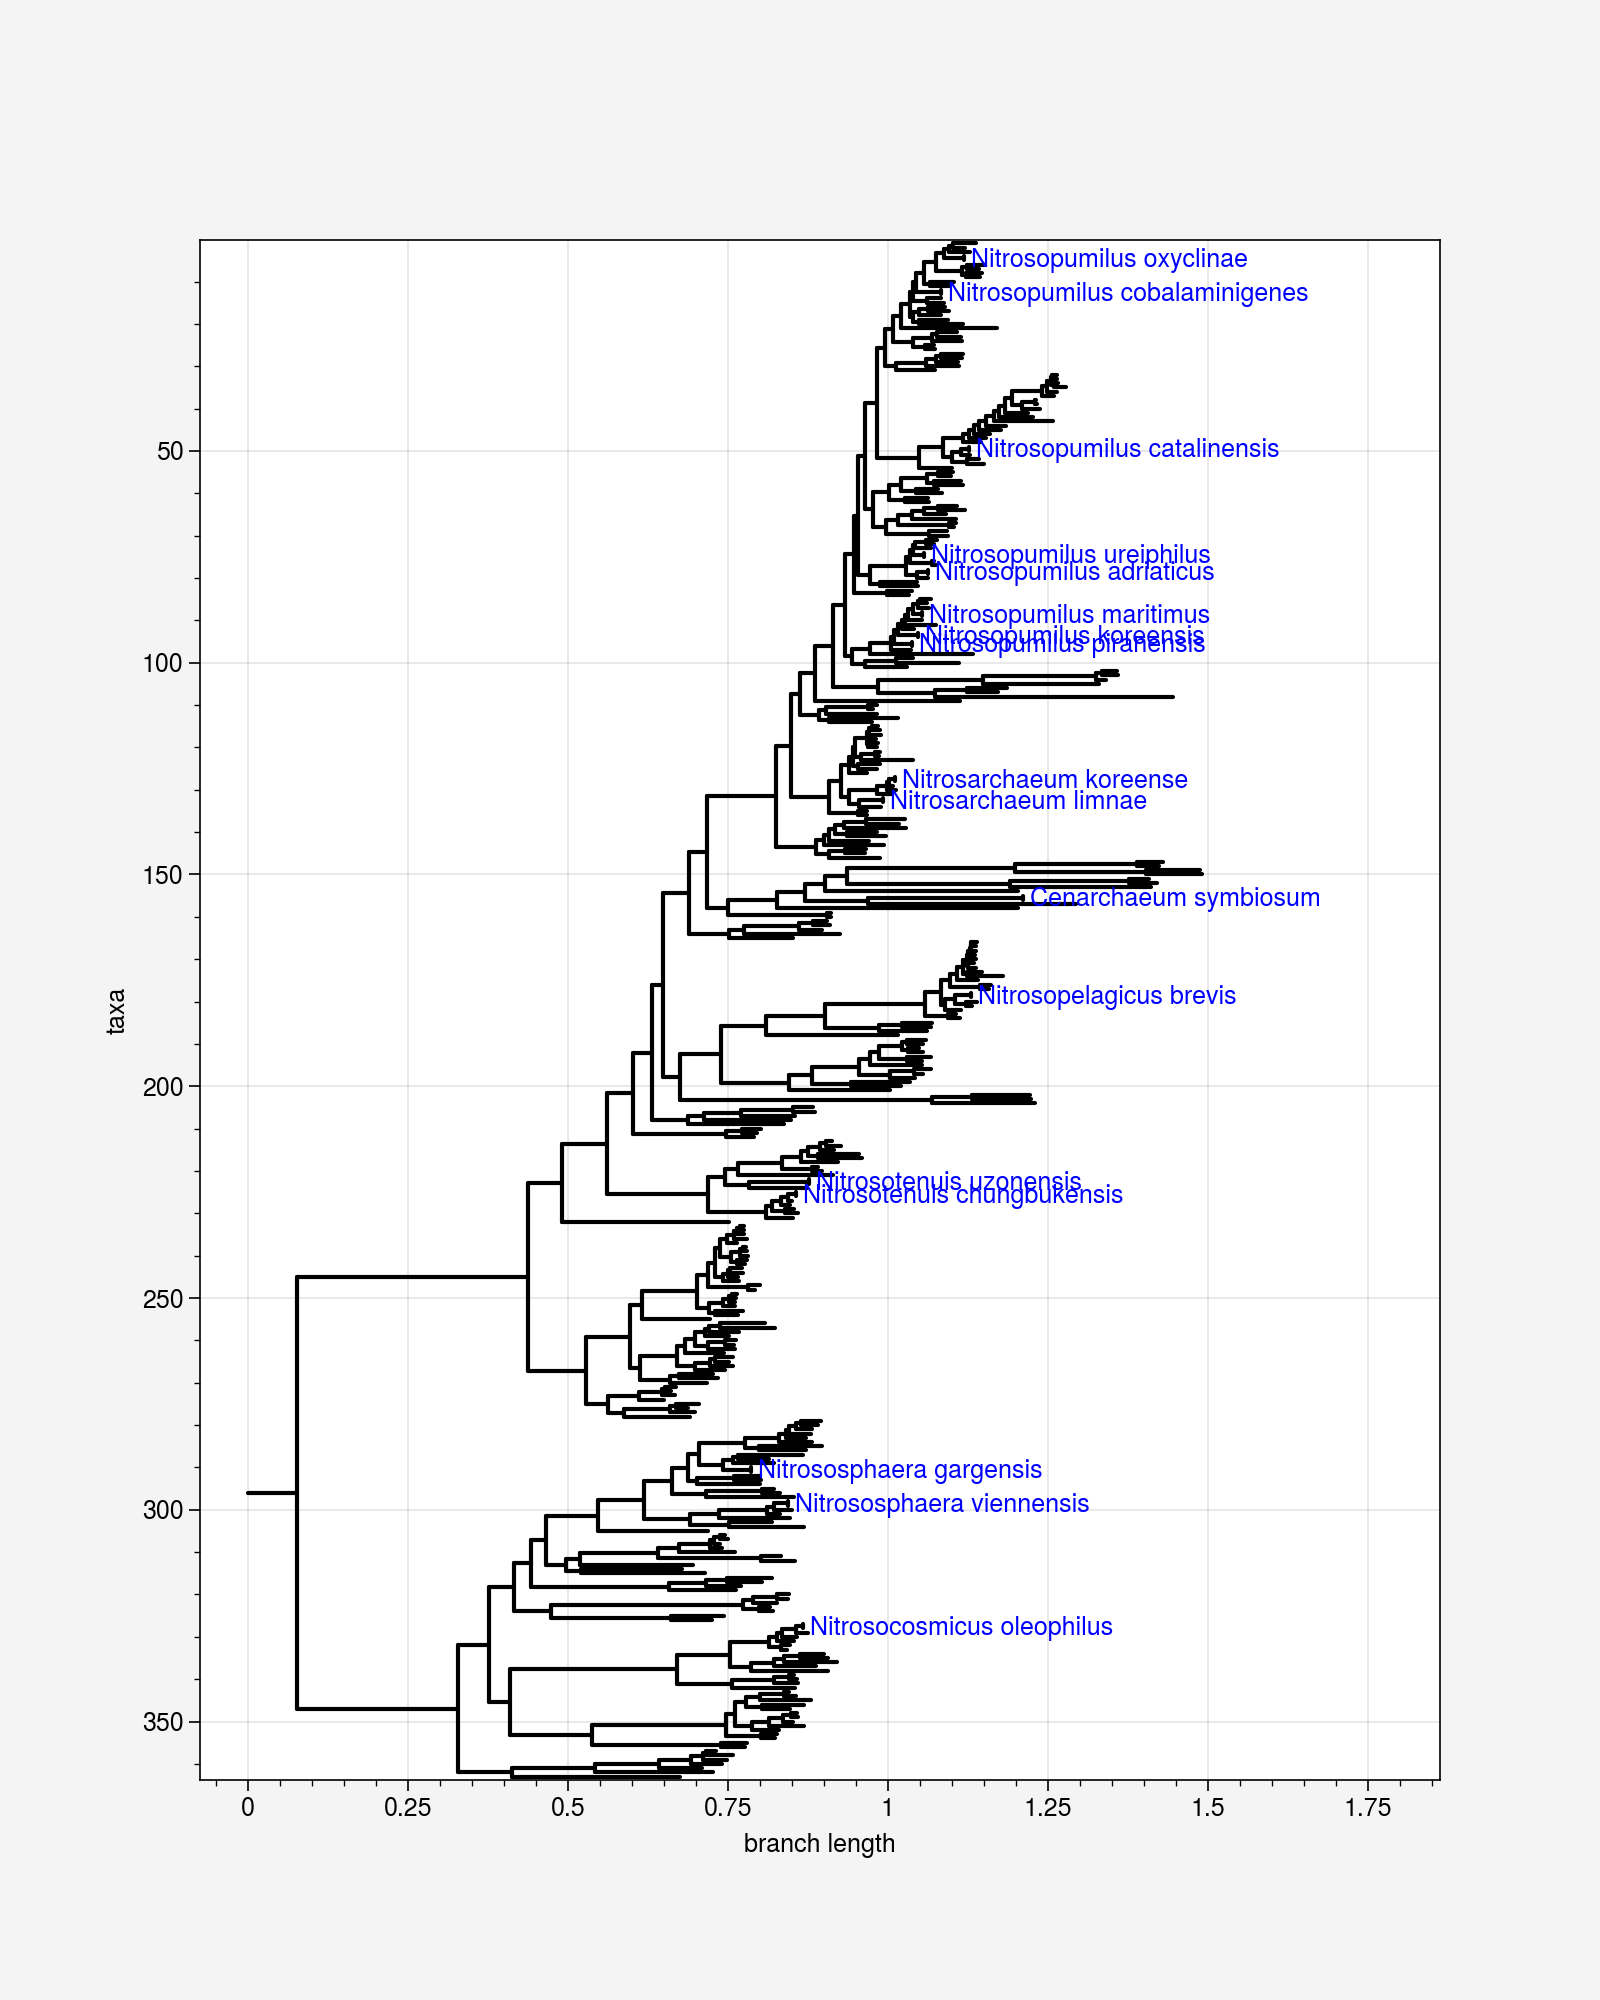

Extracted 17 species positions from Phylo.draw()
True (363.8, 0.2)
Extracted positions:
  Nitrosopumilus oxyclinae: x=1.12, y=5.00
  Nitrosopumilus cobalaminigenes: x=1.08, y=13.00
  Nitrosopumilus catalinensis: x=1.13, y=50.00
  Nitrosopumilus ureiphilus: x=1.06, y=75.00
  Nitrosopumilus adriaticus: x=1.06, y=79.00
  Nitrosopumilus maritimus: x=1.05, y=89.00
  Nitrosopumilus koreensis: x=1.05, y=94.00
  Nitrosopumilus piranensis: x=1.04, y=96.00
  Nitrosarchaeum koreense: x=1.01, y=128.00
  Nitrosarchaeum limnae: x=0.99, y=133.00
  Cenarchaeum symbiosum: x=1.21, y=156.00
  Nitrosopelagicus brevis: x=1.13, y=179.00
  Nitrosotenuis uzonensis: x=0.88, y=223.00
  Nitrosotenuis chungbukensis: x=0.86, y=226.00
  Nitrososphaera gargensis: x=0.79, y=291.00
  Nitrososphaera viennensis: x=0.84, y=299.00
  Nitrosocosmicus oleophilus: x=0.87, y=328.00
Plotted 8 bars at positions: [89, 5, 75, 50, 79, 96, 128, 156]


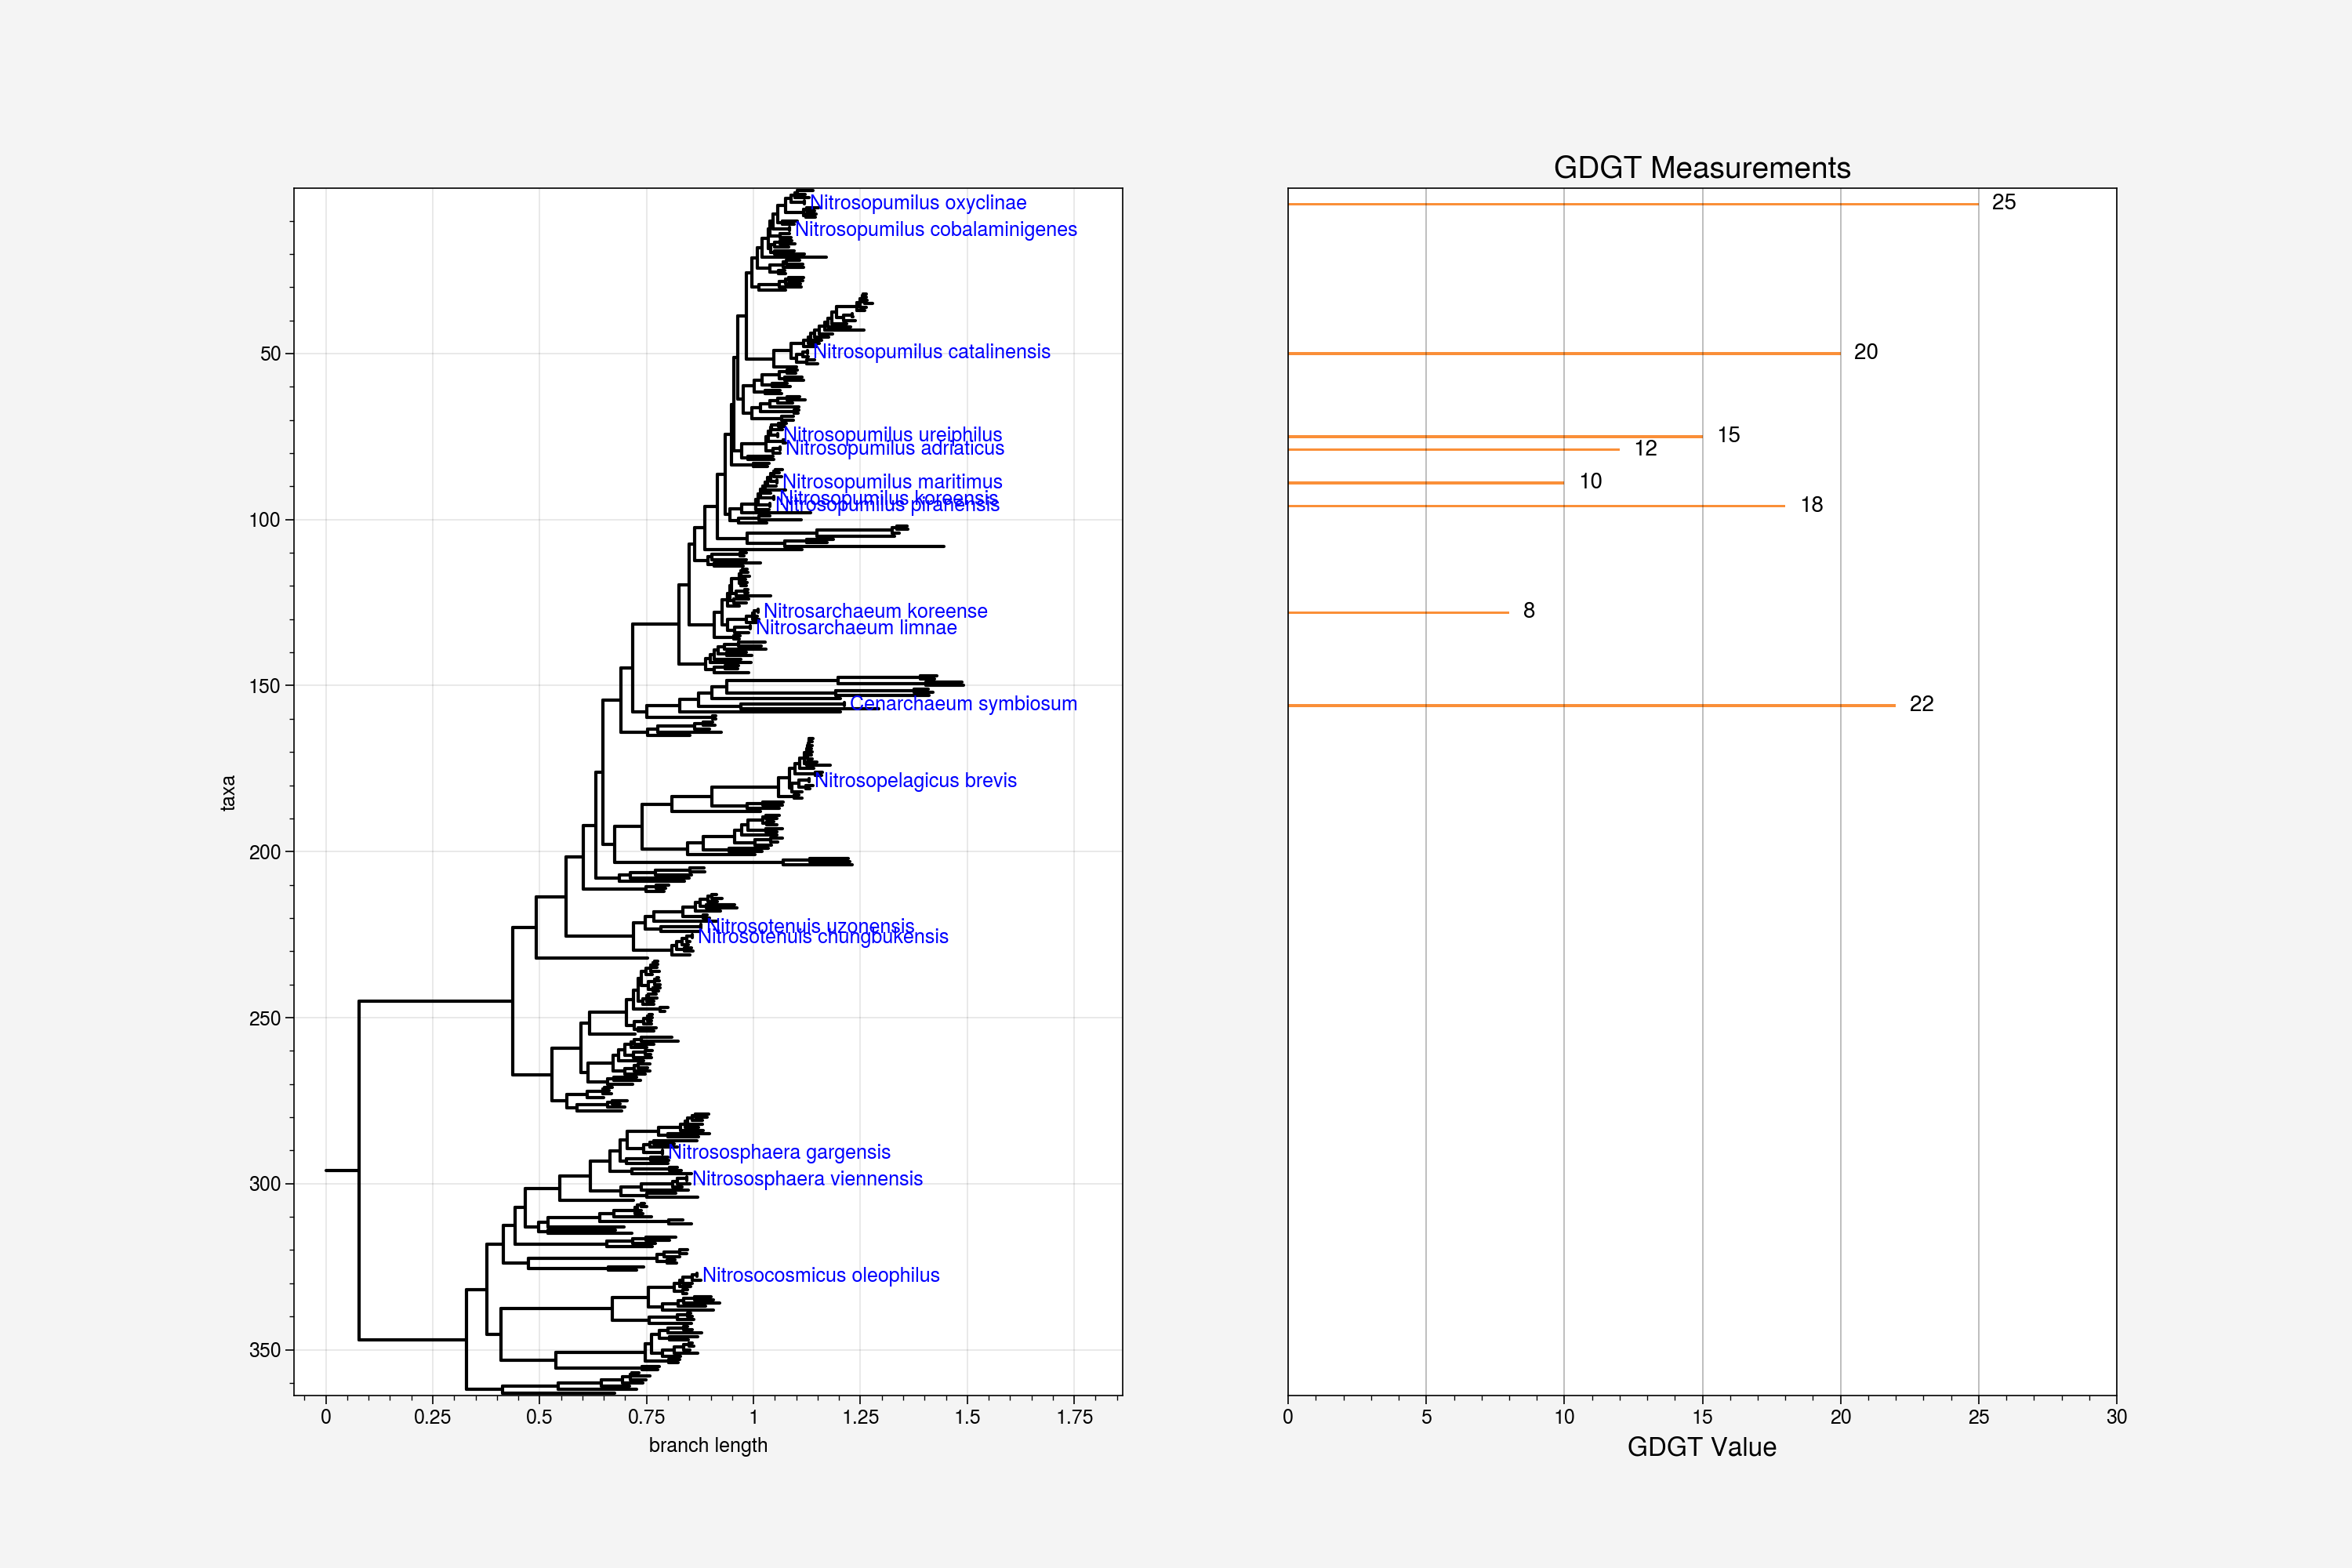

<Figure size 400x400 with 0 Axes>


Final extracted positions:
Nitrosopumilus oxyclinae: {'x': 1.11924803352, 'y': 5}
Nitrosopumilus cobalaminigenes: {'x': 1.08365293352, 'y': 13}
Nitrosopumilus catalinensis: {'x': 1.1263569535199998, 'y': 50}
Nitrosopumilus ureiphilus: {'x': 1.0568865935199998, 'y': 75}
Nitrosopumilus adriaticus: {'x': 1.06289509352, 'y': 79}
Nitrosopumilus maritimus: {'x': 1.05421895352, 'y': 89}
Nitrosopumilus koreensis: {'x': 1.04710432352, 'y': 94}
Nitrosopumilus piranensis: {'x': 1.0375737235199998, 'y': 96}
Nitrosarchaeum koreense: {'x': 1.0113199235199999, 'y': 128}
Nitrosarchaeum limnae: {'x': 0.9921958135199997, 'y': 133}
Cenarchaeum symbiosum: {'x': 1.21198781352, 'y': 156}
Nitrosopelagicus brevis: {'x': 1.13053802352, 'y': 179}
Nitrosotenuis uzonensis: {'x': 0.8770557135199999, 'y': 223}
Nitrosotenuis chungbukensis: {'x': 0.85627690352, 'y': 226}
Nitrososphaera gargensis: {'x': 0.78648261352, 'y': 291}
Nitrososphaera viennensis: {'x': 0.84362381352, 'y': 299}
Nitrosocosmicus oleophilus: {'x'

In [ ]:
from Bio import Phylo
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# ===================================================================
# --- 1. SETUP & DATA LOADING (same as before) ---
# ===================================================================

# Paths and setup code (same as your original)
# ... (your tree loading and processing code here) ...

# ===================================================================
# --- 2. EXTRACT POSITIONS FROM PHYLO.DRAW() ---
# ===================================================================

def extract_phylo_positions(tree, species_with_gdgt):
    """
    Extract species positions by running Phylo.draw() on a temporary figure
    and capturing the text positions
    """
    
    # Create a temporary figure to extract positioning info
    temp_fig, temp_ax = plt.subplots(figsize=(8, 10))
    
    # Draw tree on temporary axes
    temp_fig = Phylo.draw(tree,
               axes=temp_ax,
               label_func=lambda c: c.name if c.name in species_with_gdgt else '',
               label_colors=lambda name: 'blue' if name.strip() in species_with_gdgt else 'gray',
               show_confidence=False)
    
    # Extract text positions from the temporary plot
    species_positions = {}
    
    # Get all text objects from the plot
    for text_obj in temp_ax.texts:
        text_content = text_obj.get_text().strip()
        if text_content and text_content in species_with_gdgt:
            # Get the position of this text
            x, y = text_obj.get_position()
            species_positions[text_content] = {'x': x, 'y': y}
    
    # Get the axis limits for coordinate system info
    xlim = temp_ax.get_xlim()
    ylim = temp_ax.get_ylim()
    y_inverted = temp_ax.yaxis_inverted()
    
    # Close the temporary figure
    plt.close(temp_fig)
    
    return species_positions, xlim, ylim, y_inverted

# ===================================================================
# --- 3. ALTERNATIVE: EXTRACT FROM TREE STRUCTURE ---
# ===================================================================

def extract_positions_from_tree_structure(tree):
    """
    Alternative approach: calculate positions based on tree structure
    This mimics what Phylo.draw() does internally
    """
    
    terminals = tree.get_terminals()
    
    # Simple approach: assign y-coordinates based on terminal order
    positions = {}
    for i, terminal in enumerate(terminals):
        # Phylo.draw() typically spaces terminals evenly
        positions[terminal.name] = {
            'y': i,  # Simple integer spacing
            'x': 0   # Terminals typically at x=0 or similar
        }
    
    return positions, (0, 1), (0, len(terminals)-1), False

# ===================================================================
# --- 4. MAIN PLOTTING WITH EXTRACTED POSITIONS ---
# ===================================================================

def plot_tree_and_bars_with_extracted_positions(tree, gdgt_data, species_with_gdgt):
    """
    Plot tree and bars using pre-extracted position information
    """
    
    print("Extracting species positions from tree layout...")
    
    # Try to extract positions from Phylo.draw()
    try:
        species_positions, tree_xlim, tree_ylim, y_inverted = extract_phylo_positions(tree, species_with_gdgt)
        print(f"Extracted {len(species_positions)} species positions from Phylo.draw()")
        print(y_inverted, tree_ylim)
        # Debug: show extracted positions
        print("Extracted positions:")
        for name, pos in species_positions.items():
            print(f"  {name}: x={pos['x']:.2f}, y={pos['y']:.2f}")
            
    except Exception as e:
        print(f"Failed to extract from Phylo.draw(), using tree structure: {e}")
        species_positions, tree_xlim, tree_ylim, y_inverted = extract_positions_from_tree_structure(tree)
    
    # Create the main figure
    fig, (ax_tree, ax_bars) = plt.subplots(ncols=2, figsize=(15, 10))
    
    # STEP 1: Plot bars first (this seems to work better based on your finding)
    bar_y_positions = []
    bar_values = []
    bar_labels = []
    
    for species_name, gdgt_value in gdgt_data.items():
        if species_name in species_positions:
            y_pos = species_positions[species_name]['y']
            bar_y_positions.append(y_pos)
            bar_values.append(gdgt_value)
            bar_labels.append(species_name)
    
    if bar_y_positions:
        bars = ax_bars.barh(bar_y_positions, bar_values, color='orange', alpha=0.8)
        
        # Set coordinate system to match tree
        ax_bars.set_ylim(tree_ylim)
        
        # Format bar chart
        max_val = max(bar_values)
        ax_bars.set_xlim(0, max_val * 1.2)
        
        # Add value labels
        for y_pos, val in zip(bar_y_positions, bar_values):
            ax_bars.text(val + max_val * 0.02, y_pos, f'{val}', 
                        va='center', ha='left', fontsize=10)
        
        ax_bars.set_xlabel('GDGT Value', fontsize=12)
        ax_bars.set_title('GDGT Measurements', fontsize=14)
        ax_bars.grid(True, alpha=0.3, axis='x')
        ax_bars.set_yticks([])
        
        print(f"Plotted {len(bar_values)} bars at positions: {bar_y_positions}")
    
    # STEP 2: Plot tree second
    Phylo.draw(tree,
               axes=ax_tree,
               label_func=lambda c: c.name if c.name in species_with_gdgt else '',
               label_colors=lambda name: 'blue' if name.strip() in species_with_gdgt else 'gray',
               show_confidence=False)
    ax_tree.set_title("Focused View of the Nitrosopumilus Clade", fontsize=14)
    
    ax_bars.invert_yaxis()

    plt.tight_layout()
    plt.show()
    
    return species_positions

# ===================================================================
# --- 5. EXECUTION ---
# ===================================================================

# Your GDGT data
gdgt_data = {
    'Nitrosopumilus maritimus': 10,
    'Nitrosopumilus oxyclinae': 25,
    'Nitrosopumilus ureiphilus': 15,
    'Nitrosopumilus catalinensis': 20,
    'Nitrosopumilus adriaticus': 12,
    'Nitrosopumilus piranensis': 18,
    'Nitrosarchaeum koreense': 8,
    'Cenarchaeum symbiosum': 22,
}

# Run the extraction and plotting
extracted_positions = plot_tree_and_bars_with_extracted_positions(focused_tree, gdgt_data, species_with_gdgt)

print("\nFinal extracted positions:")
for name, pos in extracted_positions.items():
    print(f"{name}: {pos}")

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/'
fname = 'culture_mesocosm_combined_rev_030425.csv'
raw_culmeso_df = pd.read_csv(os.path.join(fpath, fname))
raw_culmeso_df

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.195035,0.060284,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.054469,0.019553,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.060683,0.018963,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.101818,0.172121,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.109714,0.266286,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.073897,0.035219,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN
173,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.051583,0.055801,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN
174,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.049939,0.045612,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN
175,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.023916,0.054250,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN


In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/'
df = pd.read_csv(f'{fpath}culture_mesocosm_combined_rev_030425.csv')

print('TAXONOMIC COLUMNS IN YOUR DATA:')
print('=' * 40)

# Check species-related columns
species_cols = ['GTDB_species', 'NCBI_species', 'GTDB_genus', 'NCBI_genus', 'Strains']

for col in species_cols:
    if col in df.columns:
        unique_count = df[col].nunique()
        non_null = df[col].notna().sum()
        print(f'{col}: {unique_count} unique values, {non_null}/{len(df)} non-null')
        
        # Show first few unique values
        unique_vals = df[col].dropna().unique()[:5]
        print(f'  Examples: {list(unique_vals)}')
        print()

print('\\nSample of your data:')
cols_to_show = ['sampleName', 'Temperature', 'TEX86'] + [col for col in species_cols if col in df.columns]
print(df[cols_to_show].head())

TAXONOMIC COLUMNS IN YOUR DATA:
GTDB_species: 11 unique values, 123/177 non-null
  Examples: ['s__Nitrosopumilus maritimus', 's__Nitrosopumilus adriaticus', 's_Nirosopumilus piranensis', 's__Nitrosopumilus ureiphilus', 's__Nitrosoarchaeum koreensis']

NCBI_species: 11 unique values, 123/177 non-null
  Examples: ['s__Nitrosopumilus maritimus', 's__Nitrosopumilus adriaticus', 's_Nirosopumilus piranensis', 's__Nitrosopumilus ureiphilus', 's__Nitrosoarchaeum koreensis']

GTDB_genus: 17 unique values, 177/177 non-null
  Examples: ['g__Nitrosotenuis', 'g__Nitrosopumilus', 'g__Nitrosarchaeum', 'g__Nitrososphaera', 'g__Cenarchaeum']

NCBI_genus: 17 unique values, 177/177 non-null
  Examples: ['g__Nitrosotenuis', 'g__Nitrosopumilus', 'g__Nitrosarchaeum', 'g__Nitrososphaera', 'g__Cenarchaeum']

Strains: 33 unique values, 177/177 non-null
  Examples: ['N4', 'NAOA2', 'NAOA6', 'SCM1', 'NF5']

\nSample of your data:
                                          sampleName  Temperature     TEX86  \
0  Ba

In [ ]:
df.columns

Index(['sampleID', 'sampleName', 'Source', 'Temperature', 'TEX86', 'ringIndex',
       'scaledRI', 'gdgt23ratio', 'phyloT_order', 'GTDB_phylum', 'NCBI_phylum',
       'GTDB_class', 'NCBI_class', 'GTDB_order', 'NCBI_order', 'GTDB_family',
       'NCBI_family', 'GTDB_genus', 'NCBI_genus', 'GTDB_species',
       'NCBI_species', 'Strains', 'experiment_setup', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'fGDGT_0', 'fGDGT_1',
       'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime', 'datatype',
       'methaneIndex', 'gdgtZeroOverZeroCren', 'BIT', 'violin_bins'],
      dtype='object')